In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('ggplot')
%matplotlib inline


In [2]:
# Загрузка данных
df = pd.read_csv('weatherAUS.csv')

# Предварительный анализ
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (145460, 23)

Первые 5 строк:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
# Базовая информация о данных
print("Информация о датасете:")
print(df.info())
print("\nПропущенные значения:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9

In [10]:
# Преобразуем дату в datetime и извлечем временные признаки
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Season'] = (df['Month'] % 12 + 3) // 3  # 1-зима, 2-весна, 3-лето, 4-осень

# Выберем числовые признаки для кластеризации
numerical_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                     'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                     'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

# Создадим дополнительные признаки
df['TempRange'] = df['MaxTemp'] - df['MinTemp']
df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']
df['HumidityDiff'] = df['Humidity3pm'] - df['Humidity9am']

numerical_features.extend(['TempRange', 'PressureDiff', 'HumidityDiff'])

In [16]:
# Обработка пропущенных значений
df_clean = df[numerical_features + ['RainToday', 'RainTomorrow']].copy()

# Заполним пропуски медианами
for col in numerical_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Закодируем категориальные переменные для оценки
le = LabelEncoder()
df_clean['RainToday_encoded'] = df_clean['RainToday'].map({'No': 0, 'Yes': 1})
df_clean['RainTomorrow_encoded'] = df_clean['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Удалим строки с пропусками в целевых переменных для оценки
df_eval = df_clean.dropna(subset=['RainToday_encoded', 'RainTomorrow_encoded']).copy()
# Удаляем категориальные столбцы из данных для кластеризации
df_for_clustering = df_eval.drop(['RainToday', 'RainTomorrow'], axis=1)

# Но сохраняем отдельно для анализа
df_categorical = df_eval[['RainToday', 'RainTomorrow']].copy()
print(f"Размер датасета после очистки: {df_eval.shape}")

Размер датасета после очистки: (140787, 23)


In [18]:
df_for_clustering.head(5)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,TempRange,PressureDiff,HumidityDiff,RainToday_encoded,RainTomorrow_encoded
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,1007.1,8.0,5.0,16.9,21.8,9.5,-0.6,-49.0,0.0,0.0
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,1007.8,5.0,5.0,17.2,24.3,17.7,-2.8,-19.0,0.0,0.0
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,1008.7,5.0,2.0,21.0,23.2,12.8,1.1,-8.0,0.0,0.0
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,1012.8,5.0,5.0,18.1,26.5,18.8,-4.8,-29.0,0.0,0.0
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,1006.0,7.0,8.0,17.8,29.7,14.8,-4.8,-49.0,0.0,0.0


In [19]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_for_clustering[numerical_features])

print("Размерность данных после масштабирования:", X_scaled.shape)

Размерность данных после масштабирования: (140787, 19)


In [20]:
df_for_clustering.head(5)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,TempRange,PressureDiff,HumidityDiff,RainToday_encoded,RainTomorrow_encoded
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,1007.1,8.0,5.0,16.9,21.8,9.5,-0.6,-49.0,0.0,0.0
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,1007.8,5.0,5.0,17.2,24.3,17.7,-2.8,-19.0,0.0,0.0
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,1008.7,5.0,2.0,21.0,23.2,12.8,1.1,-8.0,0.0,0.0
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,1012.8,5.0,5.0,18.1,26.5,18.8,-4.8,-29.0,0.0,0.0
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,1006.0,7.0,8.0,17.8,29.7,14.8,-4.8,-49.0,0.0,0.0


In [22]:
# Убедимся, что у нас чистые числовые данные
print("Проверка данных для кластеризации:")
print(f"Размерность: {df_for_clustering.shape}")
print(f"Типы данных:\n{df_for_clustering.dtypes.value_counts()}")
print(f"Пропущенные значения: {df_for_clustering.isnull().sum().sum()}")
print(f"Данные после масштабирования: {X_scaled.shape}")
print(f"Среднее: {X_scaled.mean():.2f}, Стандартное отклонение: {X_scaled.std():.2f}")

Проверка данных для кластеризации:
Размерность: (140787, 21)
Типы данных:
float64    21
Name: count, dtype: int64
Пропущенные значения: 0
Данные после масштабирования: (140787, 19)
Среднее: -0.00, Стандартное отклонение: 1.00


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Метод локтя для определения оптимального числа кластеров
inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Подбор оптимального числа кластеров для K-means...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
    # Silhouette score только если больше 1 кластера
    if k > 1:
        sil_score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(-1)
    
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

Подбор оптимального числа кластеров для K-means...
k=2: Inertia=2181152.29, Silhouette=0.171
k=3: Inertia=1917863.43, Silhouette=0.153
k=4: Inertia=1798170.21, Silhouette=0.136
k=5: Inertia=1697218.99, Silhouette=0.115
k=6: Inertia=1624791.61, Silhouette=0.119
k=7: Inertia=1558903.76, Silhouette=0.107
k=8: Inertia=1506571.08, Silhouette=0.106
k=9: Inertia=1460104.44, Silhouette=0.103
k=10: Inertia=1422608.44, Silhouette=0.101


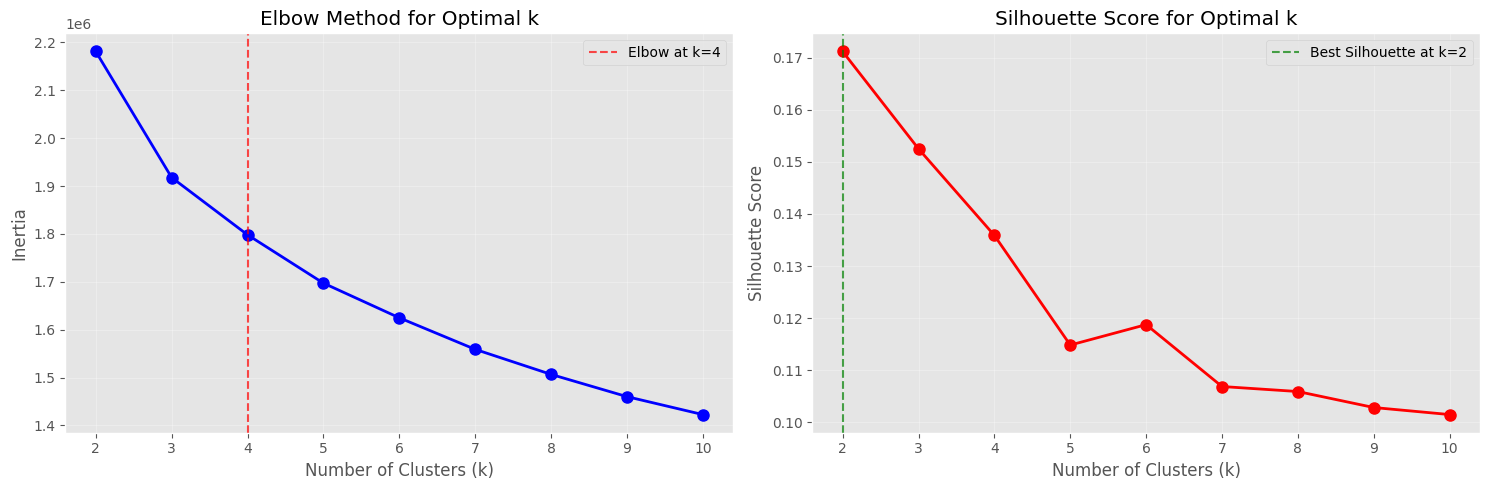

In [25]:
# Визуализация метода локтя и silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График метода локтя
ax1.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Отмечаем "локоть" на графике
elbow_k = 4  # предварительная оценка
ax1.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow at k={elbow_k}')
ax1.legend()

# График silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.grid(True, alpha=0.3)

# Находим k с максимальным silhouette score
best_sil_k = k_range[np.argmax(silhouette_scores)]
ax2.axvline(x=best_sil_k, color='green', linestyle='--', alpha=0.7, 
            label=f'Best Silhouette at k={best_sil_k}')
ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
# Анализ результатов подбора k
print("АНАЛИЗ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ:")
print("="*50)

# Находим оптимальные k по разным критериям
elbow_k = 4  # визуально с графика
best_sil_k = k_range[np.argmax(silhouette_scores)]

print(f"Метод локтя рекомендует: k = {elbow_k}")
print(f"Максимальный silhouette score: k = {best_sil_k} (score = {max(silhouette_scores):.3f})")

# Выбираем оптимальное k
optimal_k = best_sil_k  # или можно выбрать elbow_k
print(f"\nВыбранное оптимальное k: {optimal_k}")

АНАЛИЗ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ:
Метод локтя рекомендует: k = 4
Максимальный silhouette score: k = 2 (score = 0.171)

Выбранное оптимальное k: 2


In [28]:
# Обучаем финальную модель K-means с оптимальным k
print("Обучение финальной модели K-means...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Сохраняем результаты
df_analysis = df_for_clustering.copy()
df_analysis['KMeans_Cluster'] = kmeans_labels

# Добавляем обратно категориальные переменные для анализа
#df_analysis['Location'] = df_categorical['Location'].values сегодня без location 
df_analysis['RainToday'] = df_categorical['RainToday'].values  
df_analysis['RainTomorrow'] = df_categorical['RainTomorrow'].values

print("K-means обучен успешно!")
print(f"Размеры кластеров: {pd.Series(kmeans_labels).value_counts().sort_index().to_dict()}")
print(f"Final inertia: {kmeans_final.inertia_:.2f}")
print(f"Final silhouette score: {silhouette_score(X_scaled, kmeans_labels):.3f}")

Обучение финальной модели K-means...
K-means обучен успешно!
Размеры кластеров: {0: 81137, 1: 59650}
Final inertia: 2181152.29
Final silhouette score: 0.171


In [30]:
# Исправим создание DataFrame для центров
# Берем только те столбцы, которые соответствуют размерности центров
centers_df = pd.DataFrame(centers_original_scale, 
                         columns=df_for_clustering.columns[:centers_original_scale.shape[1]])
centers_df['Cluster'] = range(optimal_k)

print("Центры кластеров (в исходном масштабе):")
print(centers_df.round(2))

Центры кластеров (в исходном масштабе):
   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     9.32    18.57      3.28         4.05      7.08          38.41   
1    16.08    29.58      1.08         6.74      9.25          41.94   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
0         13.31         17.66        77.44        60.22      1019.42   
1         14.90         19.97        57.16        39.56      1015.24   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  TempRange  PressureDiff  \
0      1017.49      5.28      5.28    13.22    17.24       9.25         -1.96   
1      1012.21      3.78      3.91    22.10    27.72      13.49         -3.05   

   HumidityDiff  Cluster  
0        -17.13        0  
1        -17.69        1  


Визуализируем признаки: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed']


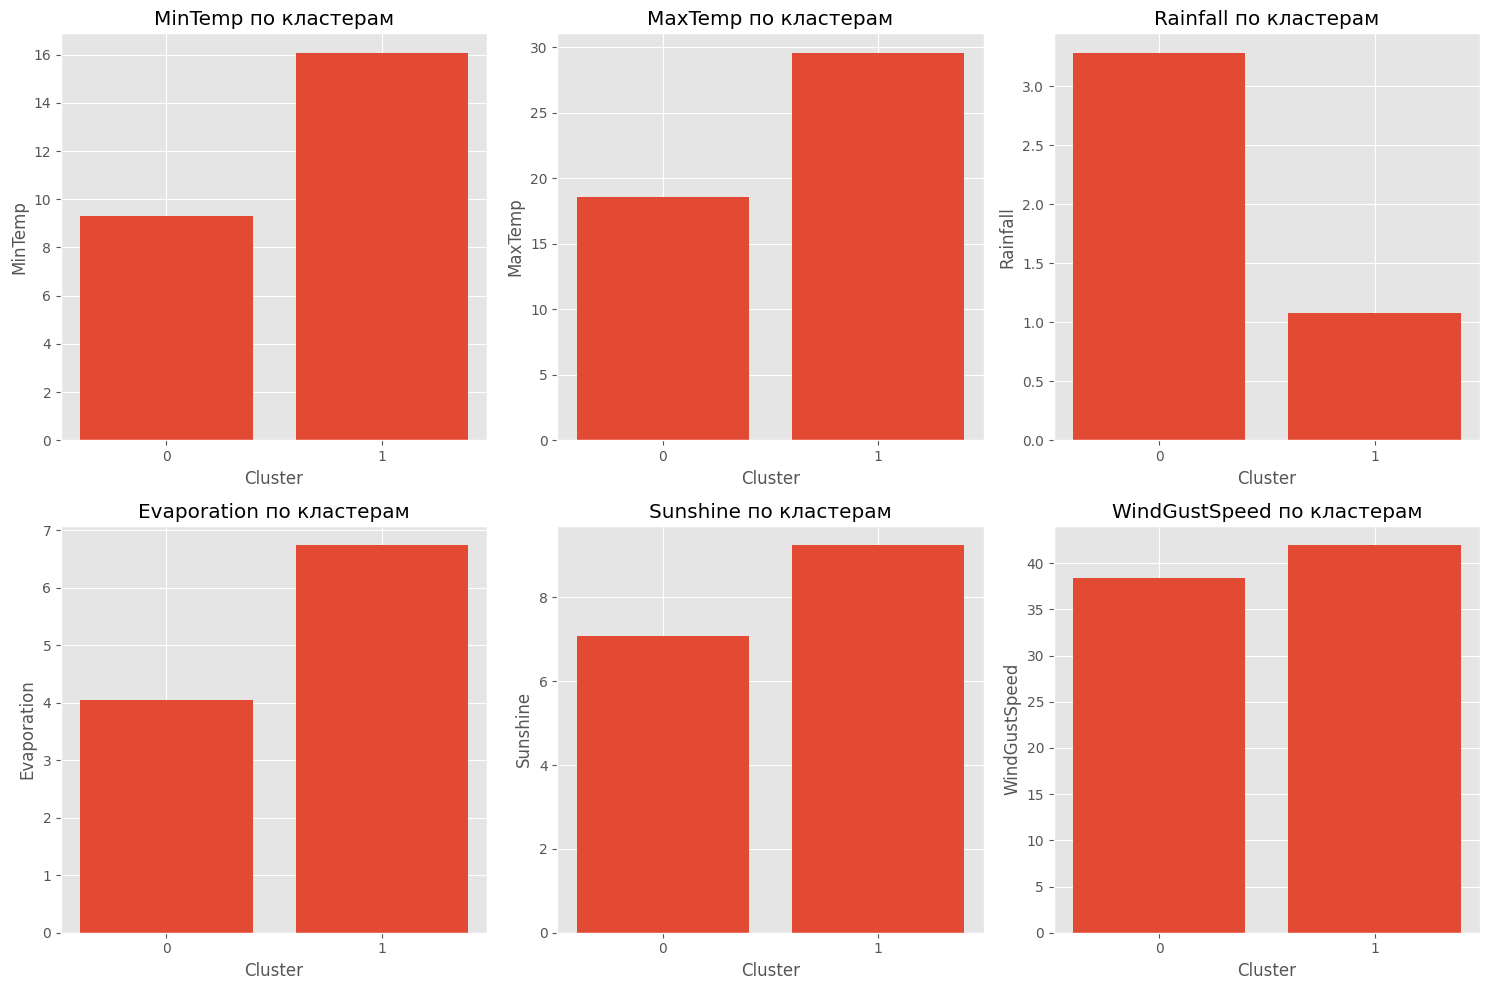

In [31]:
# Визуализация центров кластеров по ключевым признакам
# Используем только те признаки, которые есть в centers_df
available_features = centers_df.columns.tolist()
available_features.remove('Cluster')  # Убираем столбец с кластерами

# Выбираем первые 6 признаков для визуализации (или все, если меньше)
key_features = available_features[:6] if len(available_features) >= 6 else available_features

print(f"Визуализируем признаки: {key_features}")

plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    plt.bar(range(optimal_k), centers_df[feature])
    plt.title(f'{feature} по кластерам')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.xticks(range(optimal_k))

plt.tight_layout()
plt.show()

In [35]:
# Предварительная интерпретация кластеров (исправленная версия)
print("ПРЕДВАРИТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ K-MEANS:")
print("W"*60)

# Группируем по доступным признакам
cluster_profiles = df_analysis.groupby('KMeans_Cluster')[available_features].mean()

for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    
    print(f"\nКЛАСТЕР {cluster}:")
    print(f"   Размер: {len(df_analysis[df_analysis['KMeans_Cluster'] == cluster])} записей")
    
    # Используем доступные признаки для описания
    if 'MinTemp' in available_features and 'MaxTemp' in available_features:
        print(f"   Температура: {profile['MinTemp']:.1f}°C - {profile['MaxTemp']:.1f}°C")
    
    if 'Rainfall' in available_features:
        print(f"   Осадки: {profile['Rainfall']:.1f} mm")
    
    if 'Humidity9am' in available_features:
        print(f"   Влажность: {profile['Humidity9am']:.1f}%")
    
    if 'Pressure9am' in available_features:
        print(f"   Давление: {profile['Pressure9am']:.1f} hPa")

ПРЕДВАРИТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ K-MEANS:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW

КЛАСТЕР 0:
   Размер: 81137 записей
   Температура: 9.3°C - 18.6°C
   Осадки: 3.3 mm
   Влажность: 77.4%
   Давление: 1019.4 hPa

КЛАСТЕР 1:
   Размер: 59650 записей
   Температура: 16.1°C - 29.6°C
   Осадки: 1.1 mm
   Влажность: 57.2%
   Давление: 1015.2 hPa


Определение оптимального параметра eps для DBSCAN...


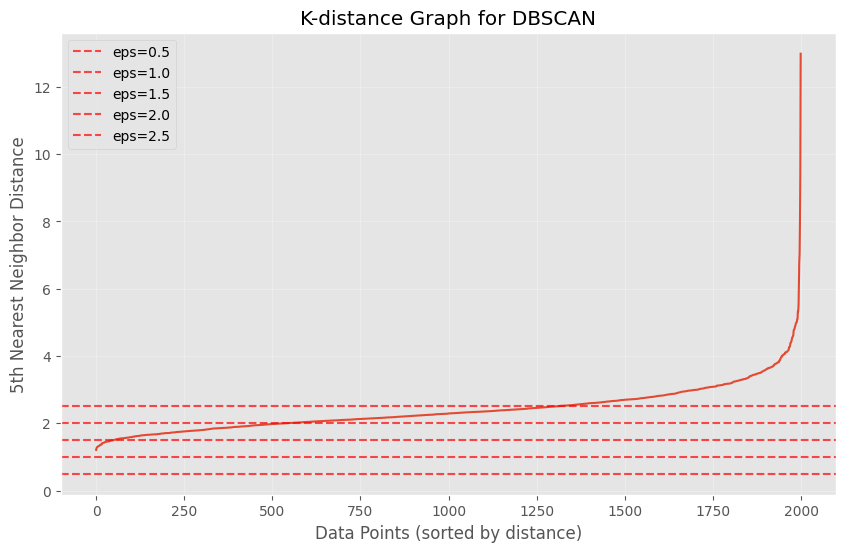

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Определяем оптимальный eps с помощью графика k-расстояний
print("Определение оптимального параметра eps для DBSCAN...")

# Используем подвыборку для скорости (если данных много)
sample_size = min(2000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Строим график k-расстояний
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_sample)
distances, indices = nn.kneighbors(X_sample)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-distance Graph for DBSCAN')
plt.grid(True, alpha=0.3)

# Добавляем возможные значения eps для тестирования
possible_eps = [0.5, 1.0, 1.5, 2.0, 2.5]
for eps in possible_eps:
    plt.axhline(y=eps, color='red', linestyle='--', alpha=0.7, label=f'eps={eps}')

plt.legend()
plt.show()

In [37]:
# Подбор параметров для DBSCAN
print("Подбор параметров для DBSCAN...")

dbscan_params = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.5, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.5, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 10},
    {'eps': 1.5, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 10},
]

dbscan_results = []

for i, params in enumerate(dbscan_params):
    dbscan = DBSCAN(**params)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    # Вычисляем silhouette score только если есть хотя бы 2 кластера
    if n_clusters > 1 and n_clusters < len(X_scaled) - 1:
        sil_score = silhouette_score(X_scaled, labels)
    else:
        sil_score = -1
        
    dbscan_results.append({
        'params': params,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette_score': sil_score,
        'labels': labels
    })
    
    print(f"DBSCAN {params}: clusters={n_clusters}, noise={n_noise} ({noise_ratio:.1%}), silhouette={sil_score:.3f}")

Подбор параметров для DBSCAN...
DBSCAN {'eps': 0.5, 'min_samples': 5}: clusters=10, noise=140625 (99.9%), silhouette=-0.365
DBSCAN {'eps': 1.0, 'min_samples': 5}: clusters=248, noise=117390 (83.4%), silhouette=-0.533
DBSCAN {'eps': 1.5, 'min_samples': 5}: clusters=136, noise=45176 (32.1%), silhouette=-0.442
DBSCAN {'eps': 2.0, 'min_samples': 5}: clusters=22, noise=10170 (7.2%), silhouette=-0.040
DBSCAN {'eps': 2.5, 'min_samples': 5}: clusters=4, noise=2495 (1.8%), silhouette=0.316
DBSCAN {'eps': 1.0, 'min_samples': 10}: clusters=53, noise=125244 (89.0%), silhouette=-0.454
DBSCAN {'eps': 1.5, 'min_samples': 10}: clusters=24, noise=55426 (39.4%), silhouette=-0.332
DBSCAN {'eps': 2.0, 'min_samples': 10}: clusters=2, noise=12639 (9.0%), silhouette=0.183


In [38]:
# Анализ результатов DBSCAN
dbscan_df = pd.DataFrame([
    {
        'eps': res['params']['eps'],
        'min_samples': res['params']['min_samples'],
        'n_clusters': res['n_clusters'],
        'n_noise': res['n_noise'],
        'noise_ratio': res['noise_ratio'],
        'silhouette_score': res['silhouette_score']
    }
    for res in dbscan_results
])

print("Результаты подбора параметров DBSCAN:")
print(dbscan_df.round(3))

Результаты подбора параметров DBSCAN:
   eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette_score
0  0.5            5          10   140625        0.999            -0.365
1  1.0            5         248   117390        0.834            -0.533
2  1.5            5         136    45176        0.321            -0.442
3  2.0            5          22    10170        0.072            -0.040
4  2.5            5           4     2495        0.018             0.316
5  1.0           10          53   125244        0.890            -0.454
6  1.5           10          24    55426        0.394            -0.332
7  2.0           10           2    12639        0.090             0.183


In [39]:
# Выбираем лучшую конфигурацию DBSCAN
# Ищем конфигурацию с хорошим silhouette score и разумным количеством шума
valid_results = [res for res in dbscan_results if res['silhouette_score'] > 0 and res['noise_ratio'] < 0.3]

if valid_results:
    best_dbscan = max(valid_results, key=lambda x: x['silhouette_score'])
else:
    # Если нет валидных результатов, берем с минимальным шумом
    best_dbscan = min(dbscan_results, key=lambda x: x['noise_ratio'])

dbscan_labels = best_dbscan['labels']

print(f"Лучшая конфигурация DBSCAN: {best_dbscan['params']}")
print(f"Кластеров: {best_dbscan['n_clusters']}")
print(f"Точек шума: {best_dbscan['n_noise']} ({best_dbscan['noise_ratio']:.1%})")
print(f"Silhouette Score: {best_dbscan['silhouette_score']:.3f}")

Лучшая конфигурация DBSCAN: {'eps': 2.5, 'min_samples': 5}
Кластеров: 4
Точек шума: 2495 (1.8%)
Silhouette Score: 0.316


In [40]:
# Сохраняем результаты DBSCAN
df_analysis['DBSCAN_Cluster'] = dbscan_labels

# Анализ кластеров DBSCAN
dbscan_cluster_sizes = pd.Series(dbscan_labels).value_counts().sort_index()
print("Размеры кластеров DBSCAN:")
print(dbscan_cluster_sizes)

# Особое внимание на шум (-1)
if -1 in dbscan_cluster_sizes:
    print(f"Точек шума: {dbscan_cluster_sizes[-1]} ({dbscan_cluster_sizes[-1]/len(dbscan_labels):.1%})")

Размеры кластеров DBSCAN:
-1      2495
 0    138277
 1         6
 2         5
 3         4
Name: count, dtype: int64
Точек шума: 2495 (1.8%)


In [41]:
# Анализ характеристик кластеров DBSCAN (исключая шум)
dbscan_cluster_profiles = df_analysis[df_analysis['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[available_features].mean()

print("ХАРАКТЕРИСТИКИ КЛАСТЕРОВ DBSCAN:")
print("="*50)

for cluster in sorted(dbscan_cluster_profiles.index):
    if cluster == -1:  # Пропускаем шум
        continue
        
    profile = dbscan_cluster_profiles.loc[cluster]
    size = dbscan_cluster_sizes[cluster]
    
    print(f"\nКЛАСТЕР {cluster}:")
    print(f"   Размер: {size} записей")
    
    if 'MinTemp' in available_features and 'MaxTemp' in available_features:
        print(f"   Температура: {profile['MinTemp']:.1f}°C - {profile['MaxTemp']:.1f}°C")
    
    if 'Rainfall' in available_features:
        print(f"   Осадки: {profile['Rainfall']:.1f} mm")
    
    if 'Humidity9am' in available_features:
        print(f"   Влажность: {profile['Humidity9am']:.1f}%")

ХАРАКТЕРИСТИКИ КЛАСТЕРОВ DBSCAN:

КЛАСТЕР 0:
   Размер: 138277 записей
   Температура: 12.1°C - 23.2°C
   Осадки: 2.0 mm
   Влажность: 68.9%

КЛАСТЕР 1:
   Размер: 6 записей
   Температура: 20.8°C - 26.6°C
   Осадки: 0.0 mm
   Влажность: 31.3%

КЛАСТЕР 2:
   Размер: 5 записей
   Температура: 19.4°C - 36.5°C
   Осадки: 0.0 mm
   Влажность: 24.2%

КЛАСТЕР 3:
   Размер: 4 записей
   Температура: 13.6°C - 19.1°C
   Осадки: 1.0 mm
   Влажность: 69.0%


In [42]:
# Сравнение K-means и DBSCAN
print("СРАВНЕНИЕ K-MEANS И DBSCAN:")
print("="*40)

comparison_data = {
    'Model': ['K-means', 'DBSCAN'],
    'Clusters': [optimal_k, best_dbscan['n_clusters']],
    'Noise Points': [0, best_dbscan['n_noise']],
    'Noise Ratio': [0, best_dbscan['noise_ratio']],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        best_dbscan['silhouette_score'] if best_dbscan['silhouette_score'] > 0 else 'N/A'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

СРАВНЕНИЕ K-MEANS И DBSCAN:
     Model  Clusters  Noise Points  Noise Ratio  Silhouette Score
0  K-means         2             0     0.000000          0.171242
1   DBSCAN         4          2495     0.017722          0.315828


In [44]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist


Построение дендрограммы на подвыборке из 500 точек...


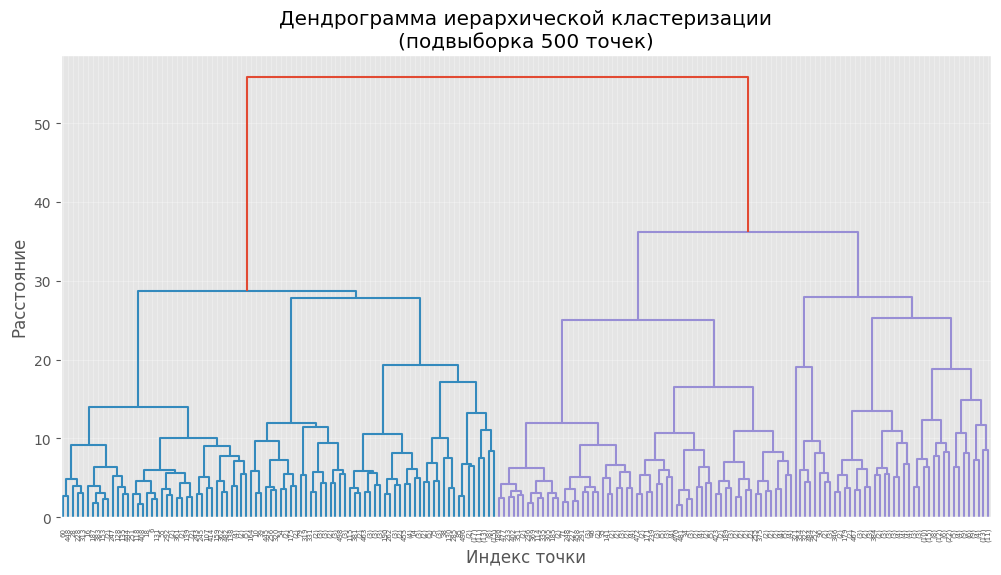

In [45]:
# Используем подвыборку для построения дендрограммы (для скорости)
sample_size_hierarchical = min(500, len(X_scaled))
sample_indices_hierarchical = np.random.choice(len(X_scaled), sample_size_hierarchical, replace=False)
X_sample_hierarchical = X_scaled[sample_indices_hierarchical]

print(f"Построение дендрограммы на подвыборке из {sample_size_hierarchical} точек...")

# Строим дендрограмму
Z = linkage(X_sample_hierarchical, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=7)
plt.title('Дендрограмма иерархической кластеризации\n(подвыборка 500 точек)')
plt.xlabel('Индекс точки')
plt.ylabel('Расстояние')
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Используем подвыборку для иерархической кластеризации
sample_size_hierarchical = min(10000, len(X_scaled))  # Увеличиваем до 10000 для репрезентативности
sample_indices_hierarchical = np.random.choice(len(X_scaled), sample_size_hierarchical, replace=False)
X_sample_hierarchical = X_scaled[sample_indices_hierarchical]

print(f"Иерархическая кластеризация на подвыборке из {sample_size_hierarchical} точек...")

# Подбор числа кластеров на подвыборке
hierarchical_scores = []
k_range_hierarchical = range(2, 8)

for n_clusters in k_range_hierarchical:
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
    labels_sample = hierarchical.fit_predict(X_sample_hierarchical)
    sil_score = silhouette_score(X_sample_hierarchical, labels_sample)
    hierarchical_scores.append(sil_score)
    print(f"Hierarchical (n_clusters={n_clusters}): silhouette={sil_score:.3f}")

Иерархическая кластеризация на подвыборке из 10000 точек...
Hierarchical (n_clusters=2): silhouette=0.132
Hierarchical (n_clusters=3): silhouette=0.094
Hierarchical (n_clusters=4): silhouette=0.091
Hierarchical (n_clusters=5): silhouette=0.074
Hierarchical (n_clusters=6): silhouette=0.060
Hierarchical (n_clusters=7): silhouette=0.062


In [49]:
# Обучаем финальную модель на подвыборке
optimal_hierarchical_k = k_range_hierarchical[np.argmax(hierarchical_scores)]
best_hierarchical_score = max(hierarchical_scores)

print(f"Оптимальное число кластеров: {optimal_hierarchical_k} (silhouette={best_hierarchical_score:.3f})")

# Для применения ко всему датасету используем K-means с тем же числом кластеров
# (это распространенный подход для больших данных)
print("Применяем K-means с тем же числом кластеров для всего датасета...")

hierarchical_kmeans = KMeans(n_clusters=optimal_hierarchical_k, random_state=42, n_init=10)
hierarchical_labels = hierarchical_kmeans.fit_predict(X_scaled)

# Сохраняем результаты
df_analysis['Hierarchical_Cluster'] = hierarchical_labels

print("Иерархическая кластеризация завершена (через K-means аппроксимацию)!")
print(f"Размеры кластеров: {pd.Series(hierarchical_labels).value_counts().sort_index().to_dict()}")
print(f"Silhouette Score на полных данных: {silhouette_score(X_scaled, hierarchical_labels):.3f}")

Оптимальное число кластеров: 2 (silhouette=0.132)
Применяем K-means с тем же числом кластеров для всего датасета...
Иерархическая кластеризация завершена (через K-means аппроксимацию)!
Размеры кластеров: {0: 81137, 1: 59650}
Silhouette Score на полных данных: 0.171


In [50]:
# Анализ характеристик кластеров иерархической кластеризации
hierarchical_cluster_profiles = df_analysis.groupby('Hierarchical_Cluster')[available_features].mean()

print("ХАРАКТЕРИСТИКИ КЛАСТЕРОВ ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИИ:")
print("W"*60)

for cluster in range(optimal_hierarchical_k):
    profile = hierarchical_cluster_profiles.loc[cluster]
    size = len(df_analysis[df_analysis['Hierarchical_Cluster'] == cluster])
    
    print(f"\nКЛАСТЕР {cluster}:")
    print(f"   Размер: {size} записей")
    
    if 'MinTemp' in available_features and 'MaxTemp' in available_features:
        print(f"   Температура: {profile['MinTemp']:.1f}°C - {profile['MaxTemp']:.1f}°C")
    
    if 'Rainfall' in available_features:
        print(f"   Осадки: {profile['Rainfall']:.1f} mm")
    
    if 'Humidity9am' in available_features:
        print(f"   Влажность: {profile['Humidity9am']:.1f}%")
    
    if 'Pressure9am' in available_features:
        print(f"   Давление: {profile['Pressure9am']:.1f} hPa")

ХАРАКТЕРИСТИКИ КЛАСТЕРОВ ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИИ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW

КЛАСТЕР 0:
   Размер: 81137 записей
   Температура: 9.3°C - 18.6°C
   Осадки: 3.3 mm
   Влажность: 77.4%
   Давление: 1019.4 hPa

КЛАСТЕР 1:
   Размер: 59650 записей
   Температура: 16.1°C - 29.6°C
   Осадки: 1.1 mm
   Влажность: 57.2%
   Давление: 1015.2 hPa


In [51]:
# Сравнение всех трех методов
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print("W"*50)

# Заранее вычисляем silhouette scores для скорости
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

comparison_data = {
    'Model': ['K-means', 'DBSCAN', 'Hierarchical'],
    'Clusters': [
        optimal_k, 
        best_dbscan['n_clusters'], 
        optimal_hierarchical_k
    ],
    'Noise Points': [
        0, 
        best_dbscan['n_noise'], 
        0
    ],
    'Noise Ratio': [
        0, 
        best_dbscan['noise_ratio'], 
        0
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        best_dbscan['silhouette_score'] if best_dbscan['silhouette_score'] > 0 else 'N/A',
        hierarchical_silhouette
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW
          Model  Clusters  Noise Points  Noise Ratio  Silhouette Score
0       K-means         2             0     0.000000          0.171242
1        DBSCAN         4          2495     0.017722          0.315828
2  Hierarchical         2             0     0.000000          0.171242


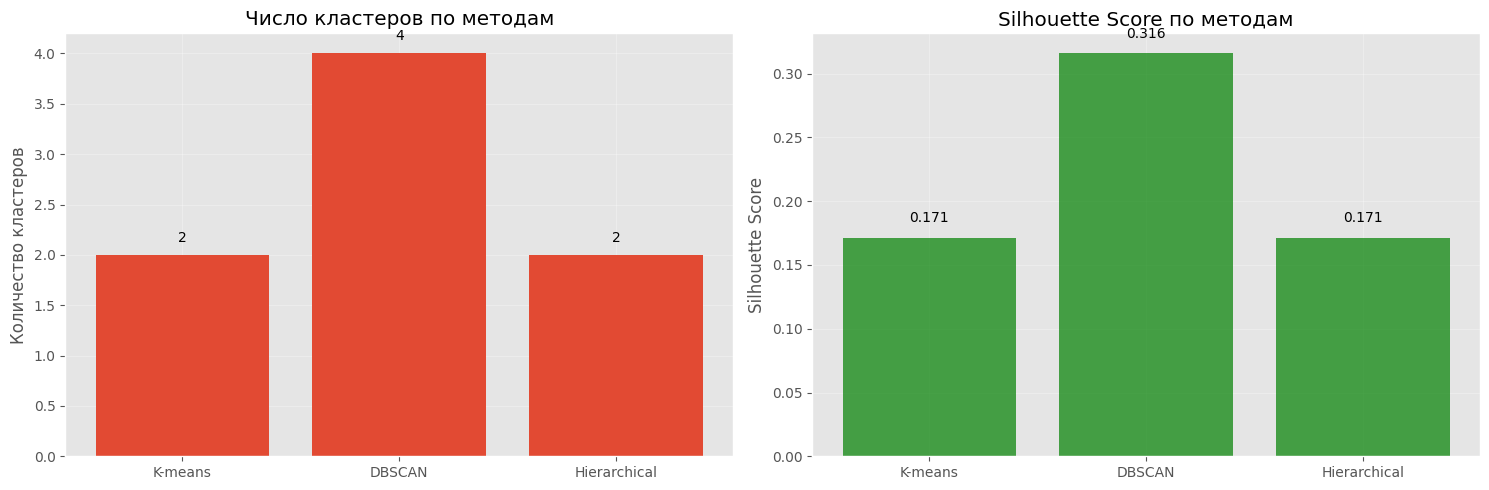

In [52]:
# Визуализация сравнения методов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График числа кластеров
models = comparison_df['Model']
clusters = comparison_df['Clusters']

bars = ax1.bar(models, clusters)
ax1.set_title('Число кластеров по методам')
ax1.set_ylabel('Количество кластеров')
ax1.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, clusters):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value}', ha='center', va='bottom')

# График silhouette scores (только валидные)
valid_scores = [score for score in comparison_df['Silhouette Score'] if score != 'N/A']
valid_models = [model for model, score in zip(models, comparison_df['Silhouette Score']) if score != 'N/A']

if valid_scores:
    bars = ax2.bar(valid_models, valid_scores, color='green', alpha=0.7)
    ax2.set_title('Silhouette Score по методам')
    ax2.set_ylabel('Silhouette Score')
    ax2.grid(True, alpha=0.3)
    
    for bar, value in zip(bars, valid_scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [53]:
print("ЭКСПЕРТНАЯ ОЦЕНКА КЛАСТЕРОВ:")
print("W"*40)

# Анализ осмысленности кластеров по ключевым погодным параметрам
key_weather_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Pressure9am']

print("\nСРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПРИЗНАКОВ ПО КЛАСТЕРАМ:")
print("K-means результаты:")

kmeans_weather_profiles = df_analysis.groupby('KMeans_Cluster')[key_weather_features].mean()
print(kmeans_weather_profiles.round(2))

ЭКСПЕРТНАЯ ОЦЕНКА КЛАСТЕРОВ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW

СРЕДНИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПРИЗНАКОВ ПО КЛАСТЕРАМ:
K-means результаты:
                MinTemp  MaxTemp  Rainfall  Humidity9am  Pressure9am
KMeans_Cluster                                                      
0                  9.32    18.57      3.29        77.43      1019.42
1                 16.08    29.58      1.08        57.15      1015.24


In [55]:
# Проверка различий между кластерами (ANOVA)
from scipy.stats import f_oneway

print("\nПРОВЕРКА СТАТИСТИЧЕСКИХ РАЗЛИЧИЙ МЕЖДУ КЛАСТЕРАМИ (K-means):")
print("W"*60)

for feature in key_weather_features:
    cluster_groups = [df_analysis[df_analysis['KMeans_Cluster'] == i][feature] for i in range(optimal_k)]
    f_stat, p_value = f_oneway(*cluster_groups)
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "незначимо"
    print(f"{feature:15}: F={f_stat:8.2f}, p-value={p_value:.6f} {significance}")


ПРОВЕРКА СТАТИСТИЧЕСКИХ РАЗЛИЧИЙ МЕЖДУ КЛАСТЕРАМИ (K-means):
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW
MinTemp        : F=52701.53, p-value=0.000000 ***
MaxTemp        : F=199333.56, p-value=0.000000 ***
Rainfall       : F= 2376.26, p-value=0.000000 ***
Humidity9am    : F=54548.95, p-value=0.000000 ***
Pressure9am    : F=14523.03, p-value=0.000000 ***


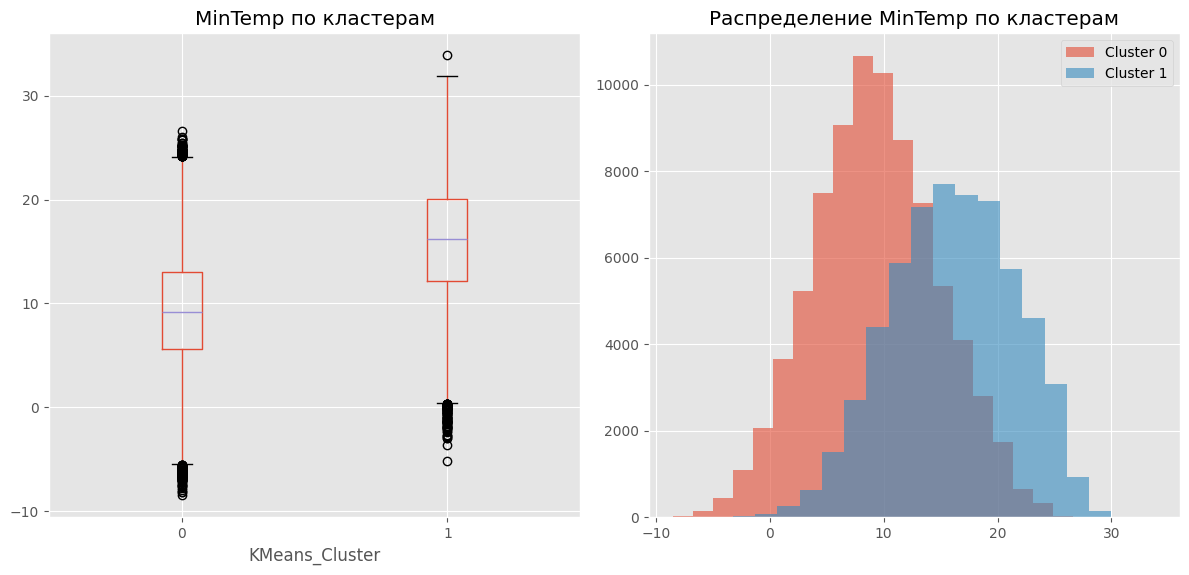

In [56]:
# Визуализируем различия для MinTemp
plt.figure(figsize=(12, 6))

# Boxplot по кластерам
plt.subplot(1, 2, 1)
df_analysis.boxplot(column='MinTemp', by='KMeans_Cluster', ax=plt.gca())
plt.title('MinTemp по кластерам')
plt.suptitle('')  # Убираем автоматический заголовок

# Гистограммы по кластерам
plt.subplot(1, 2, 2)
for cluster in range(optimal_k):
    cluster_data = df_analysis[df_analysis['KMeans_Cluster'] == cluster]['MinTemp']
    plt.hist(cluster_data, alpha=0.6, label=f'Cluster {cluster}', bins=20)
plt.title('Распределение MinTemp по кластерам')
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import numpy as np

print("ВЫЧИСЛЕНИЕ ИНДЕКСОВ ДЛЯ НАШИХ МОДЕЛЕЙ:")
print("W"*50)

models = {
    'K-means': kmeans_labels,
    'Hierarchical': hierarchical_labels
}

# DBSCAN исключаем, если только шум
if best_dbscan['n_clusters'] > 0:
    models['DBSCAN'] = dbscan_labels

results = []

for model_name, labels in models.items():
    if len(set(labels)) > 1:  # Только если есть хотя бы 2 кластера
        ch_score = calinski_harabasz_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
        
        results.append({
            'Model': model_name,
            'Clusters': len(set(labels)),
            'Calinski-Harabasz': ch_score,
            'Davies-Bouldin': db_score
        })
        
        print(f"\n{model_name}:")
        print(f"  Calinski-Harabasz: {ch_score:,.2f}")
        print(f"  Davies-Bouldin:    {db_score:.3f}")

# Создаем DataFrame для сравнения
metrics_df = pd.DataFrame(results)
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК:")
print("="*60)
print(metrics_df.round(3))

ВЫЧИСЛЕНИЕ ИНДЕКСОВ ДЛЯ НАШИХ МОДЕЛЕЙ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW

K-means:
  Calinski-Harabasz: 31,873.02
  Davies-Bouldin:    1.966

Hierarchical:
  Calinski-Harabasz: 31,873.02
  Davies-Bouldin:    1.966

DBSCAN:
  Calinski-Harabasz: 641.39
  Davies-Bouldin:    1.690

СВОДНАЯ ТАБЛИЦА МЕТРИК:
          Model  Clusters  Calinski-Harabasz  Davies-Bouldin
0       K-means         2          31873.019           1.966
1  Hierarchical         2          31873.019           1.966
2        DBSCAN         5            641.386           1.690


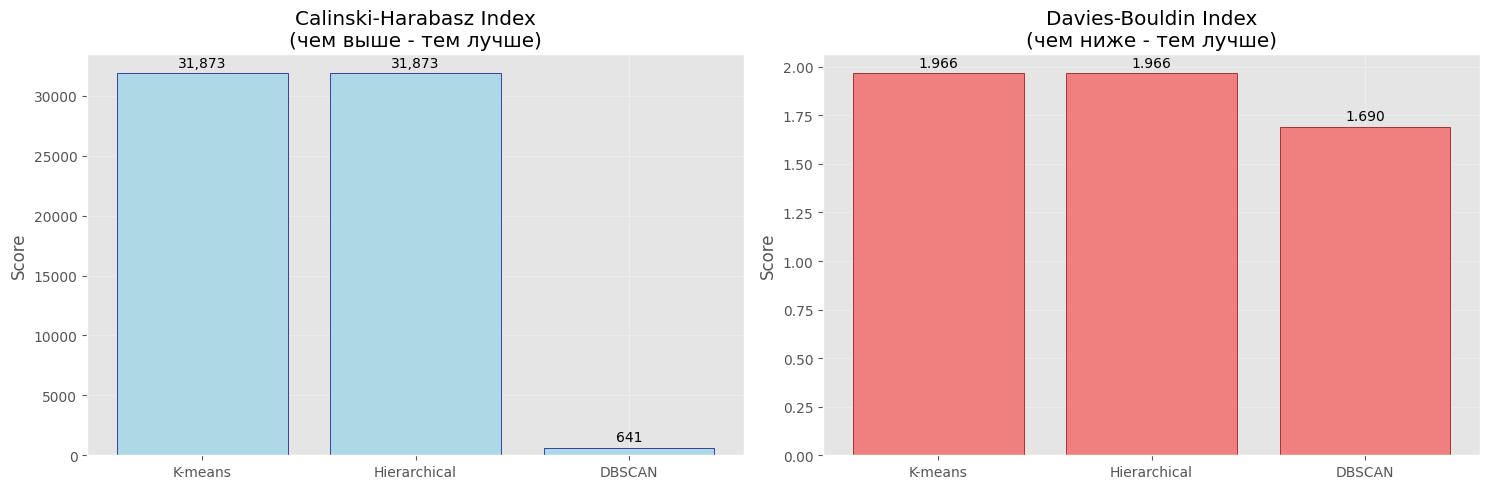

In [59]:
# Визуализация сравнения метрик
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Calinski-Harabasz (чем больше - тем лучше)
models_list = metrics_df['Model']
ch_scores = metrics_df['Calinski-Harabasz']

bars1 = ax1.bar(models_list, ch_scores, color='lightblue', edgecolor='darkblue')
ax1.set_title('Calinski-Harabasz Index\n(чем выше - тем лучше)')
ax1.set_ylabel('Score')
ax1.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars1, ch_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ch_scores)*0.01, 
             f'{value:,.0f}', ha='center', va='bottom')

# Davies-Bouldin (чем меньше - тем лучше)
db_scores = metrics_df['Davies-Bouldin']

bars2 = ax2.bar(models_list, db_scores, color='lightcoral', edgecolor='darkred')
ax2.set_title('Davies-Bouldin Index\n(чем ниже - тем лучше)')
ax2.set_ylabel('Score')
ax2.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars2, db_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(db_scores)*0.01, 
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [61]:
print("2b. СРАВНЕНИЕ С РЕАЛЬНЫМИ КЛАССАМИ:")
print("Г"+"О"*60+"Л")

2b. СРАВНЕНИЕ С РЕАЛЬНЫМИ КЛАССАМИ:
ГООООООООООООООООООООООООООООООООООООООООООООООООООООООООООООЛ


In [62]:
# Сравнение с RainToday и RainTomorrow
print("СРАВНЕНИЕ С РЕАЛЬНЫМИ ПОГОДНЫМИ ЯВЛЕНИЯМИ:")
print("="*50)

# Закодируем категориальные переменные
df_analysis['RainToday_numeric'] = df_analysis['RainToday'].map({'No': 0, 'Yes': 1})
df_analysis['RainTomorrow_numeric'] = df_analysis['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Функция для анализа связи кластеров с реальными метками
def analyze_cluster_real_relationship(cluster_col, real_col, real_name):
    # Crosstab с реальными метками
    crosstab = pd.crosstab(df_analysis[cluster_col], df_analysis[real_col], normalize='index') * 100
    
    # Adjusted Rand Score
    ar_score = adjusted_rand_score(df_analysis[real_col], df_analysis[cluster_col])
    
    # Mutual Information
    from sklearn.metrics import mutual_info_score
    mi_score = mutual_info_score(df_analysis[real_col], df_analysis[cluster_col])
    
    return crosstab, ar_score, mi_score

# Анализ для всех моделей
real_targets = {
    'RainToday': 'RainToday_numeric',
    'RainTomorrow': 'RainTomorrow_numeric'
}

results_comparison = []

for model_name in ['KMeans_Cluster', 'Hierarchical_Cluster']:
    if model_name in df_analysis.columns:
        for target_name, target_col in real_targets.items():
            crosstab, ar_score, mi_score = analyze_cluster_real_relationship(model_name, target_col, target_name)
            
            # Находим кластер с максимальной долей "Yes"
            if 1 in crosstab.columns:
                max_rain_cluster = crosstab[1].idxmax()
                max_rain_percent = crosstab[1].max()
            else:
                max_rain_cluster = -1
                max_rain_percent = 0
                
            results_comparison.append({
                'Model': model_name.replace('_Cluster', ''),
                'Target': target_name,
                'Adjusted_Rand_Score': ar_score,
                'Mutual_Info_Score': mi_score,
                'Max_Rain_Cluster': max_rain_cluster,
                'Max_Rain_Percent': max_rain_percent
            })
            
            print(f"\n{model_name} vs {target_name}:")
            print(f"  Adjusted Rand Score: {ar_score:.4f}")
            print(f"  Mutual Info Score: {mi_score:.4f}")
            print(f"  Максимальная доля дождя: кластер {max_rain_cluster} ({max_rain_percent:.1f}%)")

СРАВНЕНИЕ С РЕАЛЬНЫМИ ПОГОДНЫМИ ЯВЛЕНИЯМИ:

KMeans_Cluster vs RainToday:
  Adjusted Rand Score: 0.0061
  Mutual Info Score: 0.0314
  Максимальная доля дождя: кластер 0 (31.0%)

KMeans_Cluster vs RainTomorrow:
  Adjusted Rand Score: -0.0031
  Mutual Info Score: 0.0172
  Максимальная доля дождя: кластер 0 (28.6%)

Hierarchical_Cluster vs RainToday:
  Adjusted Rand Score: 0.0061
  Mutual Info Score: 0.0314
  Максимальная доля дождя: кластер 0 (31.0%)

Hierarchical_Cluster vs RainTomorrow:
  Adjusted Rand Score: -0.0031
  Mutual Info Score: 0.0172
  Максимальная доля дождя: кластер 0 (28.6%)


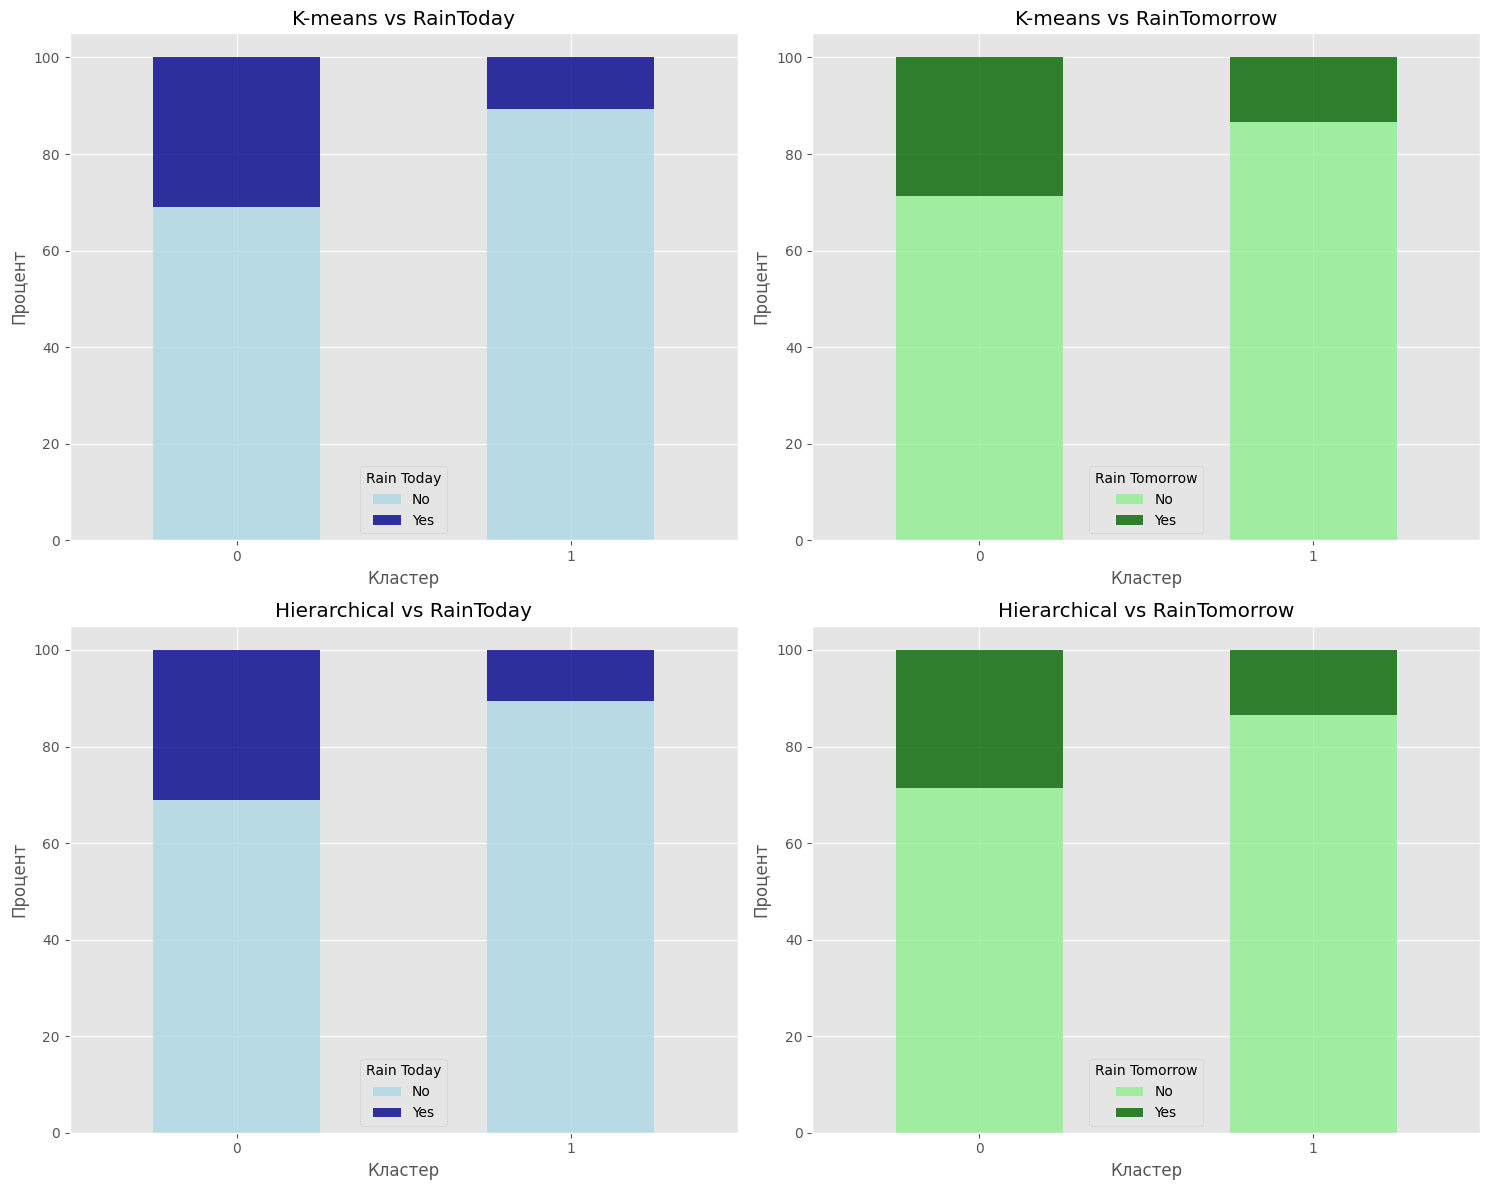

In [63]:
# Визуализация связи кластеров с реальными метками
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# K-means vs RainToday
rain_today_kmeans = pd.crosstab(df_analysis['KMeans_Cluster'], 
                               df_analysis['RainToday'], 
                               normalize='index') * 100
rain_today_kmeans.plot(kind='bar', stacked=True, ax=axes[0,0], 
                      color=['lightblue', 'darkblue'], alpha=0.8)
axes[0,0].set_title('K-means vs RainToday')
axes[0,0].set_xlabel('Кластер')
axes[0,0].set_ylabel('Процент')
axes[0,0].legend(title='Rain Today')
axes[0,0].tick_params(axis='x', rotation=0)

# K-means vs RainTomorrow
rain_tomorrow_kmeans = pd.crosstab(df_analysis['KMeans_Cluster'], 
                                  df_analysis['RainTomorrow'], 
                                  normalize='index') * 100
rain_tomorrow_kmeans.plot(kind='bar', stacked=True, ax=axes[0,1], 
                         color=['lightgreen', 'darkgreen'], alpha=0.8)
axes[0,1].set_title('K-means vs RainTomorrow')
axes[0,1].set_xlabel('Кластер')
axes[0,1].set_ylabel('Процент')
axes[0,1].legend(title='Rain Tomorrow')
axes[0,1].tick_params(axis='x', rotation=0)

# Hierarchical vs RainToday
rain_today_hierarchical = pd.crosstab(df_analysis['Hierarchical_Cluster'], 
                                     df_analysis['RainToday'], 
                                     normalize='index') * 100
rain_today_hierarchical.plot(kind='bar', stacked=True, ax=axes[1,0], 
                            color=['lightblue', 'darkblue'], alpha=0.8)
axes[1,0].set_title('Hierarchical vs RainToday')
axes[1,0].set_xlabel('Кластер')
axes[1,0].set_ylabel('Процент')
axes[1,0].legend(title='Rain Today')
axes[1,0].tick_params(axis='x', rotation=0)

# Hierarchical vs RainTomorrow
rain_tomorrow_hierarchical = pd.crosstab(df_analysis['Hierarchical_Cluster'], 
                                        df_analysis['RainTomorrow'], 
                                        normalize='index') * 100
rain_tomorrow_hierarchical.plot(kind='bar', stacked=True, ax=axes[1,1], 
                               color=['lightgreen', 'darkgreen'], alpha=0.8)
axes[1,1].set_title('Hierarchical vs RainTomorrow')
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Процент')
axes[1,1].legend(title='Rain Tomorrow')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [64]:
# Анализ "дождливых" кластеров
print("АНАЛИЗ 'ДОЖДЛИВЫХ' КЛАСТЕРОВ:")
print("W"*40)

for model_name in ['KMeans_Cluster', 'Hierarchical_Cluster']:
    if model_name in df_analysis.columns:
        print(f"\n{model_name}:")
        
        # Анализ для RainTomorrow
        rain_tomorrow_by_cluster = df_analysis.groupby(model_name)['RainTomorrow_numeric'].mean() * 100
        
        # Находим самый "дождливый" кластер
        rainiest_cluster = rain_tomorrow_by_cluster.idxmax()
        rainiest_percent = rain_tomorrow_by_cluster.max()
        
        # Находим самый "сухой" кластер
        driest_cluster = rain_tomorrow_by_cluster.idxmin()
        driest_percent = rain_tomorrow_by_cluster.min()
        
        print(f"  Самый дождливый кластер: {rainiest_cluster} ({rainiest_percent:.1f}% дождливых дней)")
        print(f"  Самый сухой кластер: {driest_cluster} ({driest_percent:.1f}% дождливых дней)")
        print(f"  Разница: {rainiest_percent - driest_percent:.1f}%")

АНАЛИЗ 'ДОЖДЛИВЫХ' КЛАСТЕРОВ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW

KMeans_Cluster:
  Самый дождливый кластер: 0 (28.6% дождливых дней)
  Самый сухой кластер: 1 (13.4% дождливых дней)
  Разница: 15.3%

Hierarchical_Cluster:
  Самый дождливый кластер: 0 (28.6% дождливых дней)
  Самый сухой кластер: 1 (13.4% дождливых дней)
  Разница: 15.3%


In [65]:
# Статистическая значимость различий между кластерами по RainTomorrow
from scipy.stats import chi2_contingency

print("ПРОВЕРКА СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ:")
print("="*50)

for model_name in ['KMeans_Cluster', 'Hierarchical_Cluster']:
    if model_name in df_analysis.columns:
        # Создаем таблицу сопряженности
        contingency_table = pd.crosstab(df_analysis[model_name], df_analysis['RainTomorrow'])
        
        # Тест хи-квадрат
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        print(f"\n{model_name} vs RainTomorrow:")
        print(f"  Chi-square: {chi2:.2f}")
        print(f"  p-value: {p_value:.6f}")
        print(f"  Статистически значимо: {'ДА' if p_value < 0.05 else 'НЕТ'}")

ПРОВЕРКА СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ:

KMeans_Cluster vs RainTomorrow:
  Chi-square: 4639.09
  p-value: 0.000000
  Статистически значимо: ДА

Hierarchical_Cluster vs RainTomorrow:
  Chi-square: 4639.09
  p-value: 0.000000
  Статистически значимо: ДА


In [67]:
# Проверяем DBSCAN и добавляем его в анализ
if 'DBSCAN_Cluster' in df_analysis.columns:
    # Проверяем, есть ли нешумовые кластеры в DBSCAN
    dbscan_non_noise = df_analysis[df_analysis['DBSCAN_Cluster'] != -1]
    
    if len(dbscan_non_noise) > 0 and dbscan_non_noise['DBSCAN_Cluster'].nunique() > 1:
        # DBSCAN создал кластеры (не только шум)
        models_to_compare = ['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']
        print("DBSCAN создал кластеры - добавляем в сравнение")
    else:
        # DBSCAN создал только шум или один кластер
        models_to_compare = ['KMeans_Cluster', 'Hierarchical_Cluster']
        print("DBSCAN создал только шум/один кластер - исключаем из сравнения")
else:
    models_to_compare = ['KMeans_Cluster', 'Hierarchical_Cluster']
    print("DBSCAN не обучен - исключаем из сравнения")

print(f"Модели для сравнения: {models_to_compare}")

DBSCAN создал кластеры - добавляем в сравнение
Модели для сравнения: ['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']


In [68]:
# Обновляем анализ с учетом DBSCAN
results_comparison = []

for model_name in models_to_compare:
    if model_name in df_analysis.columns:
        # Проверяем, есть ли достаточно кластеров для сравнения
        n_clusters = df_analysis[model_name].nunique()
        if model_name == 'DBSCAN_Cluster' and -1 in df_analysis[model_name].values:
            n_clusters -= 1  # Исключаем шум из подсчета
        
        if n_clusters >= 2:  # Только если есть хотя бы 2 кластера
            for target_name, target_col in real_targets.items():
                crosstab, ar_score, mi_score = analyze_cluster_real_relationship(model_name, target_col, target_name)
                
                # Находим кластер с максимальной долей "Yes"
                if 1 in crosstab.columns:
                    # Для DBSCAN исключаем шум (-1) из анализа
                    if model_name == 'DBSCAN_Cluster' and -1 in crosstab.index:
                        crosstab_no_noise = crosstab.drop(-1, errors='ignore')
                        if len(crosstab_no_noise) > 0:
                            max_rain_cluster = crosstab_no_noise[1].idxmax()
                            max_rain_percent = crosstab_no_noise[1].max()
                        else:
                            max_rain_cluster = -1
                            max_rain_percent = 0
                    else:
                        max_rain_cluster = crosstab[1].idxmax()
                        max_rain_percent = crosstab[1].max()
                else:
                    max_rain_cluster = -1
                    max_rain_percent = 0
                    
                results_comparison.append({
                    'Model': model_name.replace('_Cluster', ''),
                    'Target': target_name,
                    'Adjusted_Rand_Score': ar_score,
                    'Mutual_Info_Score': mi_score,
                    'Max_Rain_Cluster': max_rain_cluster,
                    'Max_Rain_Percent': max_rain_percent,
                    'N_Clusters': n_clusters
                })
                
                print(f"\n{model_name} vs {target_name}:")
                print(f"  Кластеров: {n_clusters}")
                print(f"  Adjusted Rand Score: {ar_score:.4f}")
                print(f"  Mutual Info Score: {mi_score:.4f}")
                if max_rain_percent > 0:
                    print(f"  Максимальная доля дождя: кластер {max_rain_cluster} ({max_rain_percent:.1f}%)")
        else:
            print(f"\n{model_name}: недостаточно кластеров для сравнения (n={n_clusters})")


KMeans_Cluster vs RainToday:
  Кластеров: 2
  Adjusted Rand Score: 0.0061
  Mutual Info Score: 0.0314
  Максимальная доля дождя: кластер 0 (31.0%)

KMeans_Cluster vs RainTomorrow:
  Кластеров: 2
  Adjusted Rand Score: -0.0031
  Mutual Info Score: 0.0172
  Максимальная доля дождя: кластер 0 (28.6%)

Hierarchical_Cluster vs RainToday:
  Кластеров: 2
  Adjusted Rand Score: 0.0061
  Mutual Info Score: 0.0314
  Максимальная доля дождя: кластер 0 (31.0%)

Hierarchical_Cluster vs RainTomorrow:
  Кластеров: 2
  Adjusted Rand Score: -0.0031
  Mutual Info Score: 0.0172
  Максимальная доля дождя: кластер 0 (28.6%)

DBSCAN_Cluster vs RainToday:
  Кластеров: 4
  Adjusted Rand Score: 0.0286
  Mutual Info Score: 0.0031
  Максимальная доля дождя: кластер 3 (25.0%)

DBSCAN_Cluster vs RainTomorrow:
  Кластеров: 4
  Adjusted Rand Score: 0.0313
  Mutual Info Score: 0.0036
  Максимальная доля дождя: кластер 0 (21.6%)


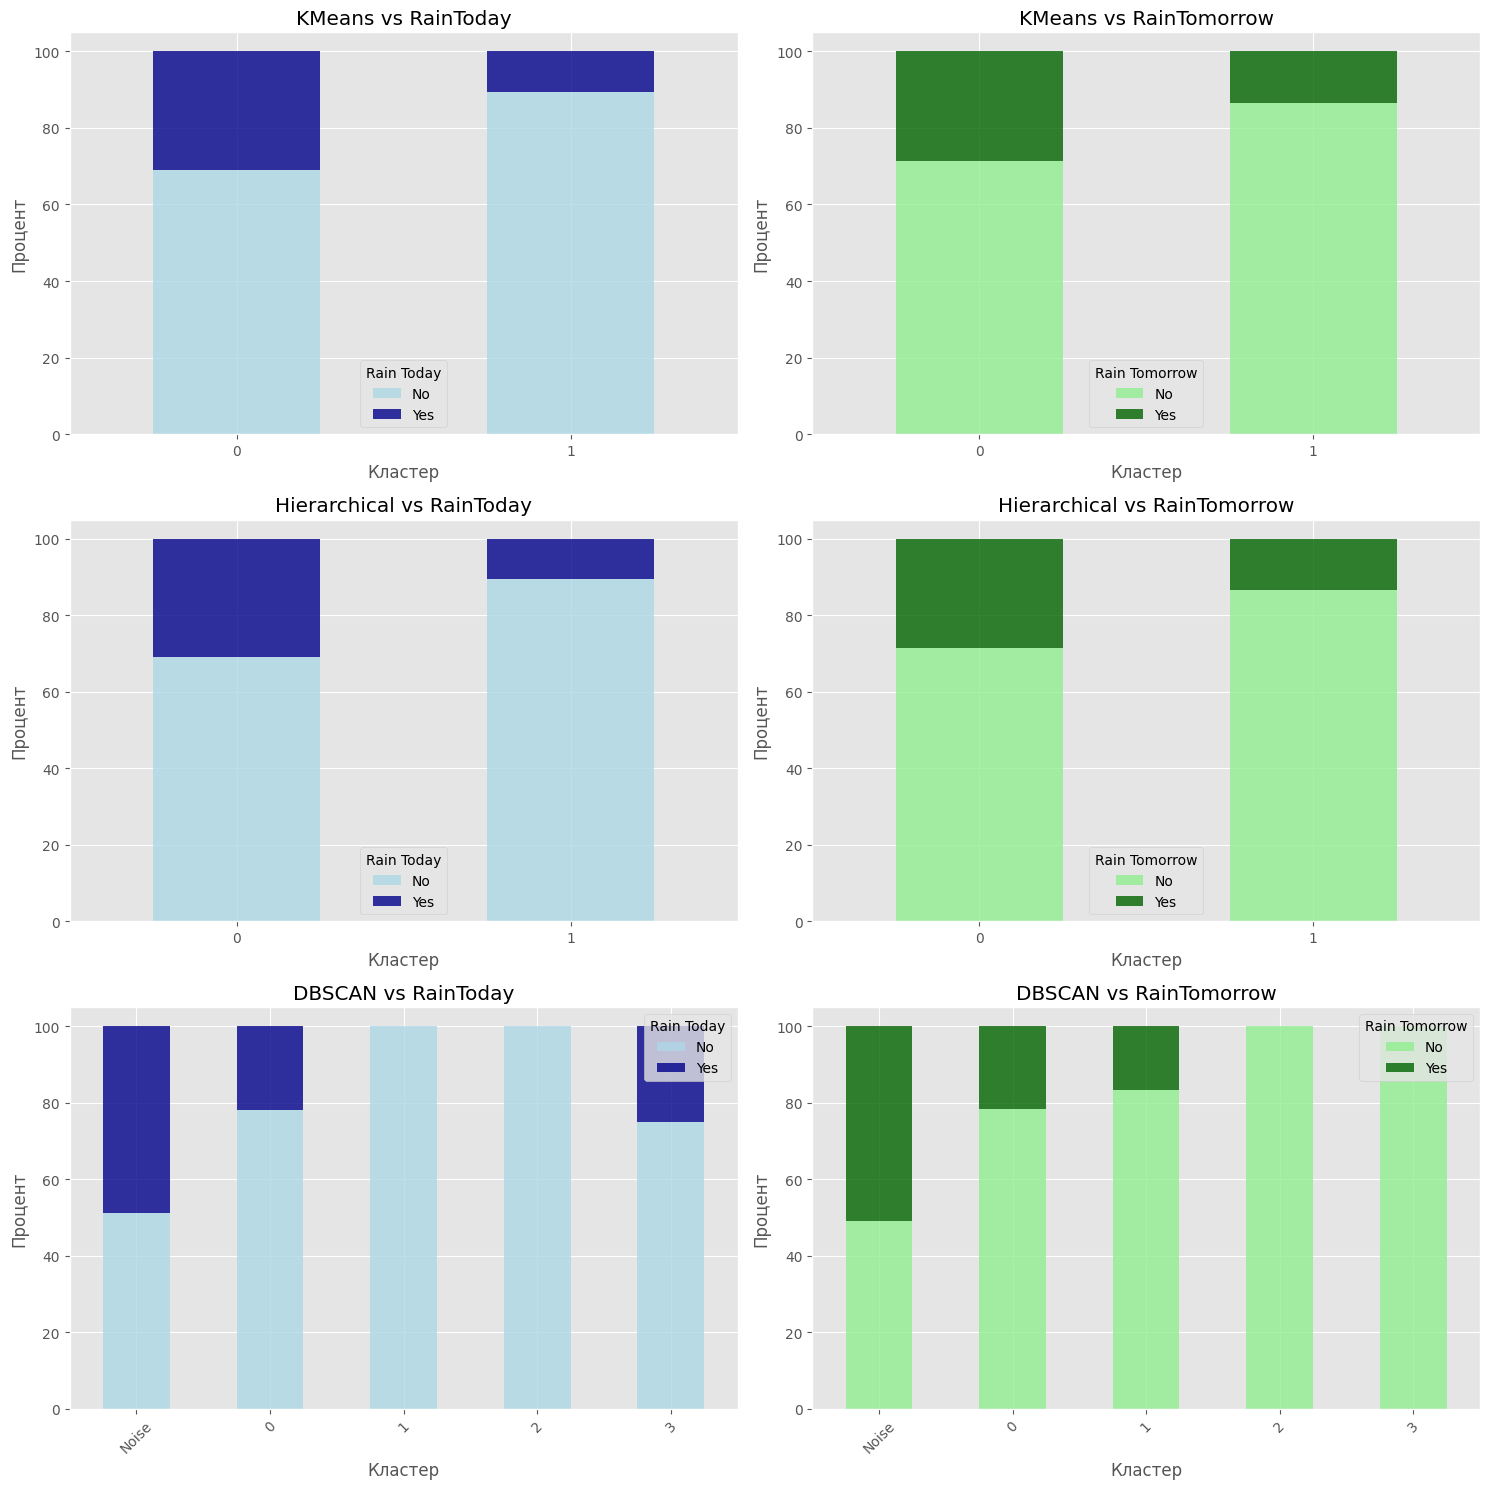

In [69]:
# Визуализация для всех моделей включая DBSCAN
n_models = len(models_to_compare)
fig, axes = plt.subplots(n_models, 2, figsize=(15, 5 * n_models))

if n_models == 1:
    axes = axes.reshape(1, -1)

for i, model_name in enumerate(models_to_compare):
    if model_name in df_analysis.columns:
        model_display_name = model_name.replace('_Cluster', '')
        
        # RainToday
        rain_today_data = pd.crosstab(df_analysis[model_name], 
                                    df_analysis['RainToday'], 
                                    normalize='index') * 100
        
        # Для DBSCAN можем переименовать шум для лучшей читаемости
        if model_name == 'DBSCAN_Cluster' and -1 in rain_today_data.index:
            rain_today_data = rain_today_data.rename({-1: 'Noise'})
        
        rain_today_data.plot(kind='bar', stacked=True, ax=axes[i, 0], 
                           color=['lightblue', 'darkblue'], alpha=0.8)
        axes[i, 0].set_title(f'{model_display_name} vs RainToday')
        axes[i, 0].set_xlabel('Кластер')
        axes[i, 0].set_ylabel('Процент')
        axes[i, 0].legend(title='Rain Today')
        axes[i, 0].tick_params(axis='x', rotation=45 if model_name == 'DBSCAN_Cluster' else 0)
        
        # RainTomorrow
        rain_tomorrow_data = pd.crosstab(df_analysis[model_name], 
                                       df_analysis['RainTomorrow'], 
                                       normalize='index') * 100
        
        if model_name == 'DBSCAN_Cluster' and -1 in rain_tomorrow_data.index:
            rain_tomorrow_data = rain_tomorrow_data.rename({-1: 'Noise'})
        
        rain_tomorrow_data.plot(kind='bar', stacked=True, ax=axes[i, 1], 
                              color=['lightgreen', 'darkgreen'], alpha=0.8)
        axes[i, 1].set_title(f'{model_display_name} vs RainTomorrow')
        axes[i, 1].set_xlabel('Кластер')
        axes[i, 1].set_ylabel('Процент')
        axes[i, 1].legend(title='Rain Tomorrow')
        axes[i, 1].tick_params(axis='x', rotation=45 if model_name == 'DBSCAN_Cluster' else 0)

plt.tight_layout()
plt.show()

In [70]:
# Анализ качества DBSCAN отдельно
if 'DBSCAN_Cluster' in df_analysis.columns:
    print("ДЕТАЛЬНЫЙ АНАЛИЗ DBSCAN:")
    print("="*40)
    
    dbscan_stats = df_analysis['DBSCAN_Cluster'].value_counts().sort_index()
    print("Распределение по кластерам DBSCAN:")
    print(dbscan_stats)
    
    # Анализ шума
    if -1 in dbscan_stats.index:
        noise_count = dbscan_stats[-1]
        noise_ratio = noise_count / len(df_analysis)
        print(f"\nТочек шума: {noise_count} ({noise_ratio:.1%})")
        
        # Анализ характеристик шума
        noise_data = df_analysis[df_analysis['DBSCAN_Cluster'] == -1]
        if len(noise_data) > 0:
            print("\nХарактеристики шумовых точек:")
            print(f"- Средняя температура: {noise_data['MinTemp'].mean():.1f}°C - {noise_data['MaxTemp'].mean():.1f}°C")
            print(f"- Средние осадки: {noise_data['Rainfall'].mean():.1f} mm")
            print(f"- Доля дождливых дней: {noise_data['RainTomorrow_numeric'].mean()*100:.1f}%")

ДЕТАЛЬНЫЙ АНАЛИЗ DBSCAN:
Распределение по кластерам DBSCAN:
DBSCAN_Cluster
-1      2495
 0    138277
 1         6
 2         5
 3         4
Name: count, dtype: int64

Точек шума: 2495 (1.8%)

Характеристики шумовых точек:
- Средняя температура: 14.7°C - 24.7°C
- Средние осадки: 20.5 mm
- Доля дождливых дней: 51.0%


In [80]:
print("2c. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАННЫХ ЗНАЧЕНИЙ:")
print("W"*45)

2c. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАННЫХ ЗНАЧЕНИЙ:
WWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWW


In [81]:
# PCA для уменьшения размерности до 2D для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.3f}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}, PC2: {pca.explained_variance_ratio_[1]:.3f}")

Объясненная дисперсия PCA: 0.482
PC1: 0.284, PC2: 0.198


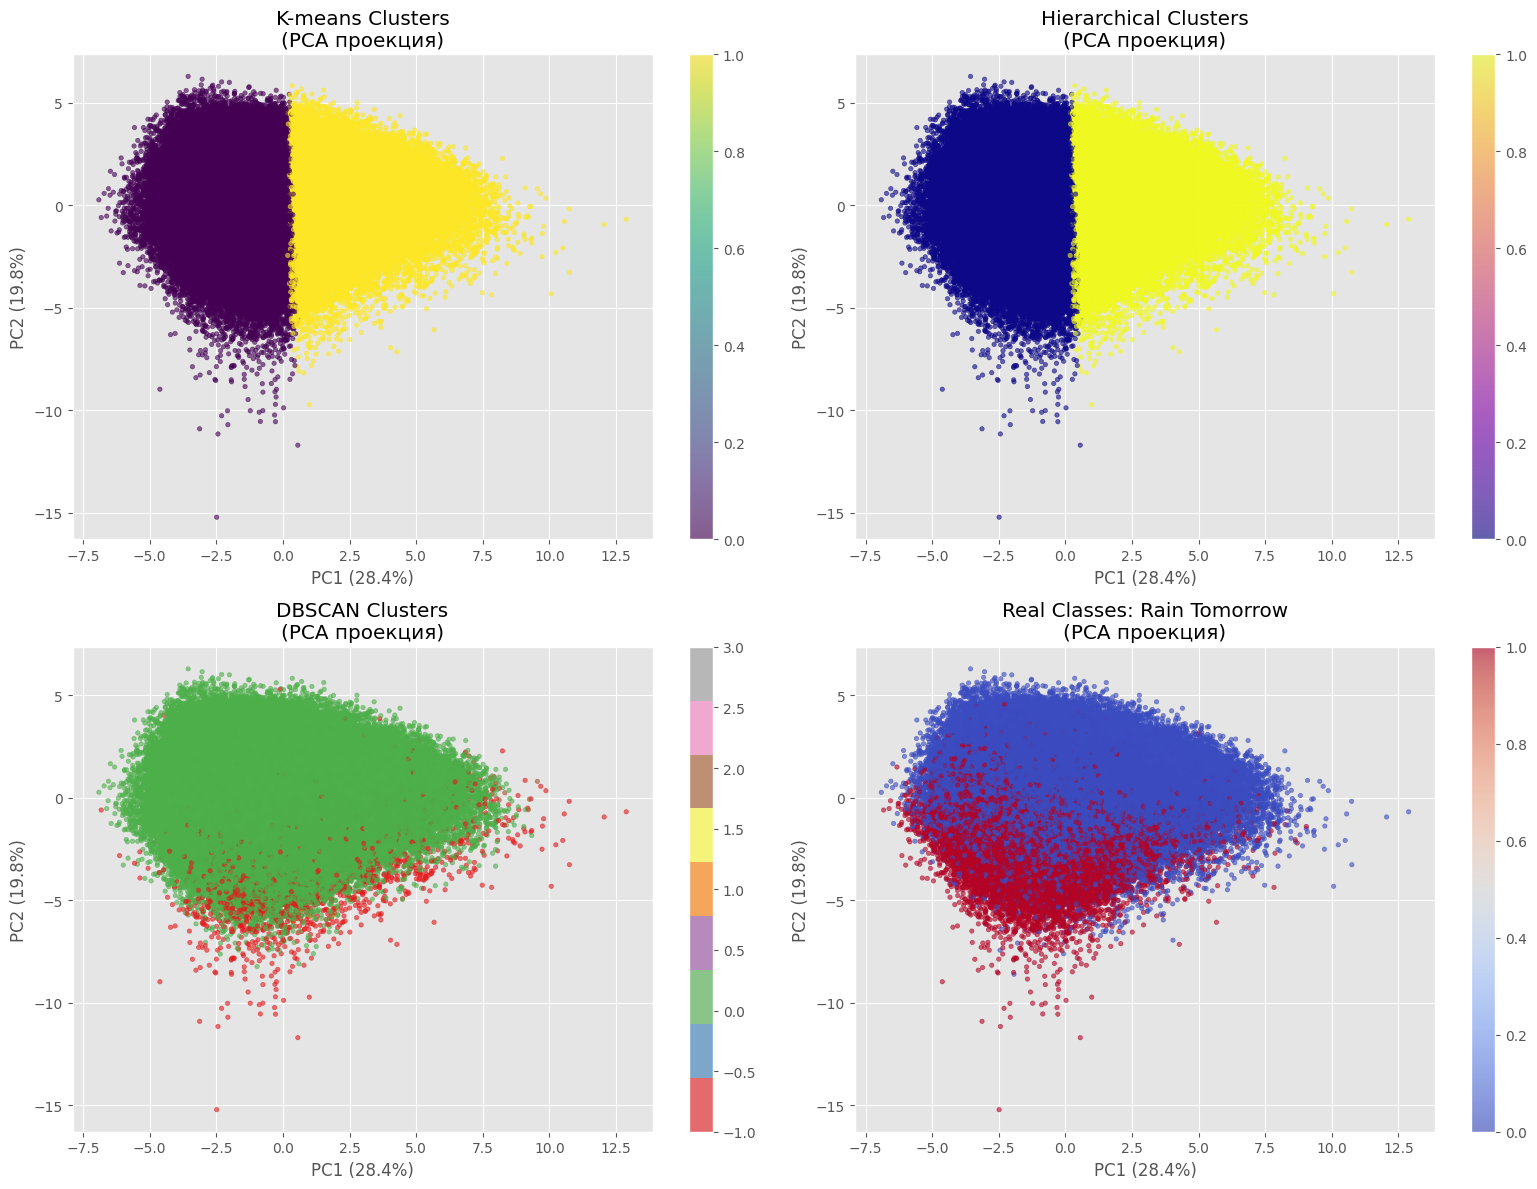

In [82]:
# Визуализация кластеров в 2D пространстве PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. K-means кластеры
scatter1 = axes[0,0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                            cmap='viridis', alpha=0.6, s=10)
axes[0,0].set_title('K-means Clusters\n(PCA проекция)')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0,0])

# 2. Иерархические кластеры
scatter2 = axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, 
                            cmap='plasma', alpha=0.6, s=10)
axes[0,1].set_title('Hierarchical Clusters\n(PCA проекция)')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter2, ax=axes[0,1])

# 3. DBSCAN кластеры (если есть)
if 'DBSCAN_Cluster' in df_analysis.columns:
    scatter3 = axes[1,0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, 
                                cmap='Set1', alpha=0.6, s=10)
    axes[1,0].set_title('DBSCAN Clusters\n(PCA проекция)')
    axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter3, ax=axes[1,0])
else:
    axes[1,0].text(0.5, 0.5, 'DBSCAN не обучен', ha='center', va='center', 
                  transform=axes[1,0].transAxes, fontsize=12)
    axes[1,0].set_title('DBSCAN Clusters')

# 4. Реальные классы (RainTomorrow)
rain_tomorrow_numeric = df_analysis['RainTomorrow_numeric'].values
scatter4 = axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1], c=rain_tomorrow_numeric, 
                            cmap='coolwarm', alpha=0.6, s=10)
axes[1,1].set_title('Real Classes: Rain Tomorrow\n(PCA проекция)')
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter4, ax=axes[1,1])

plt.tight_layout()
plt.show()

Объясненная дисперсия 3D PCA: 0.588


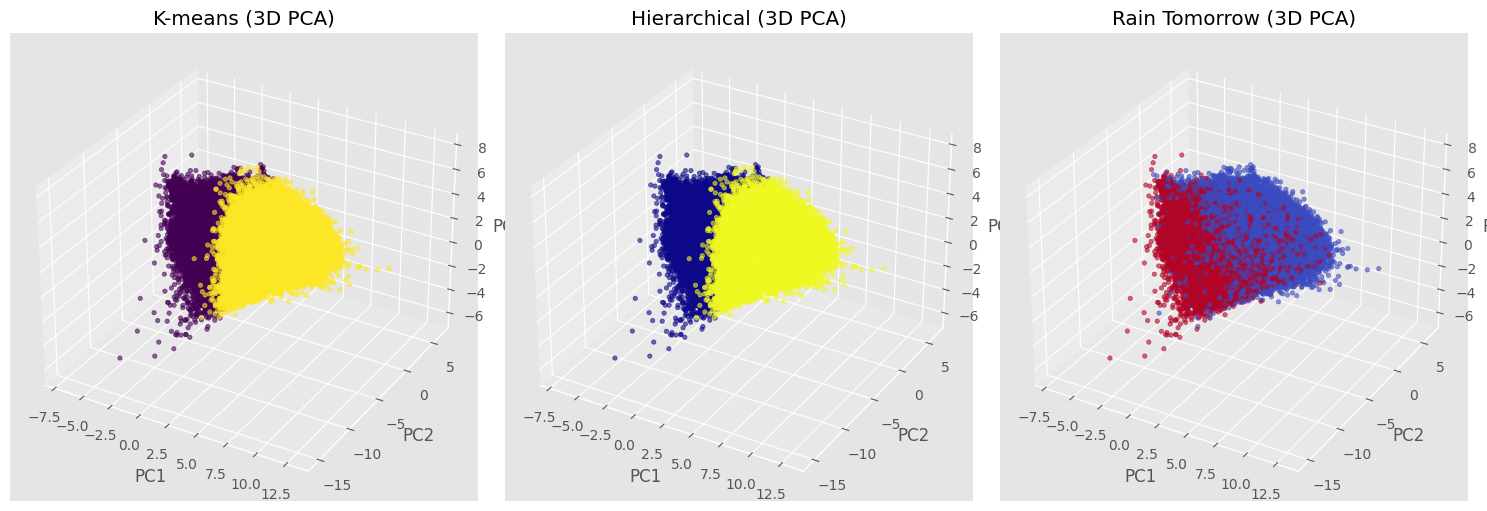

In [83]:
# 3D визуализация (если нужно больше измерений)
from mpl_toolkits.mplot3d import Axes3D

# PCA с 3 компонентами для 3D визуализации
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"Объясненная дисперсия 3D PCA: {pca_3d.explained_variance_ratio_.sum():.3f}")

fig = plt.figure(figsize=(15, 5))

# K-means в 3D
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter3D(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                        c=kmeans_labels, cmap='viridis', alpha=0.6, s=10)
ax1.set_title('K-means (3D PCA)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# Иерархические в 3D
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter3D(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                        c=hierarchical_labels, cmap='plasma', alpha=0.6, s=10)
ax2.set_title('Hierarchical (3D PCA)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Реальные классы в 3D
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter3D(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                        c=rain_tomorrow_numeric, cmap='coolwarm', alpha=0.6, s=10)
ax3.set_title('Rain Tomorrow (3D PCA)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')

plt.tight_layout()
plt.show()

In [85]:
# Создаем centers_df с правильными столбцами
centers_df = pd.DataFrame(centers_original, 
                         columns=df_for_clustering.columns[:centers_original.shape[1]])
centers_df['Cluster'] = range(optimal_k)

print("Центры кластеров K-means:")
print(centers_df.round(2))

Центры кластеров K-means:
   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0     9.32    18.57      3.28         4.05      7.08          38.41   
1    16.08    29.58      1.08         6.74      9.25          41.94   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
0         13.31         17.66        77.44        60.22      1019.42   
1         14.90         19.97        57.16        39.56      1015.24   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  TempRange  PressureDiff  \
0      1017.49      5.28      5.28    13.22    17.24       9.25         -1.96   
1      1012.21      3.78      3.91    22.10    27.72      13.49         -3.05   

   HumidityDiff  Cluster  
0        -17.13        0  
1        -17.69        1  


Визуализируем признаки: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed']


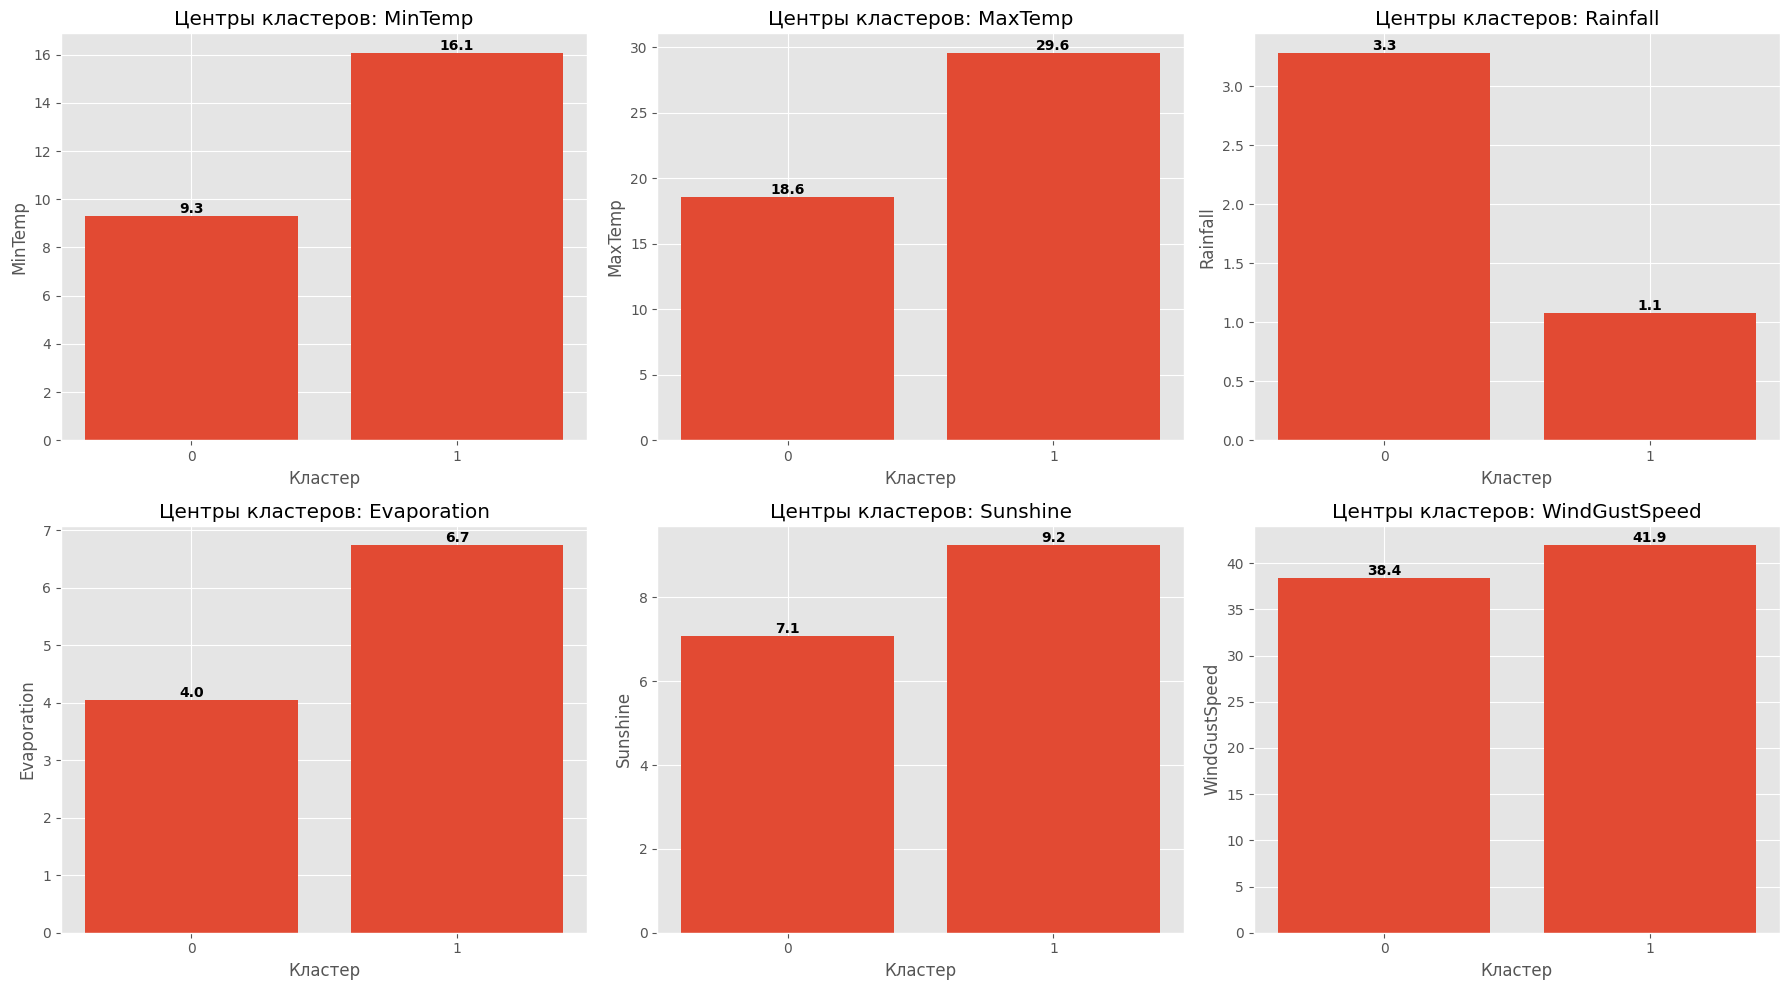

In [86]:
# Визуализация центров по доступным признакам
available_features = centers_df.columns.tolist()
available_features.remove('Cluster')  # Убираем столбец с кластерами

# Выбираем первые 6 признаков для визуализации
top_features = available_features[:6] if len(available_features) >= 6 else available_features
print(f"Визуализируем признаки: {top_features}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    if i < len(axes):  # Защита от выхода за границы
        axes[i].bar(range(optimal_k), centers_df[feature])
        axes[i].set_title(f'Центры кластеров: {feature}')
        axes[i].set_xlabel('Кластер')
        axes[i].set_ylabel(feature)
        axes[i].set_xticks(range(optimal_k))
        
        # Добавляем значения на столбцы
        for j, value in enumerate(centers_df[feature]):
            axes[i].text(j, value, f'{value:.1f}', 
                        ha='center', va='bottom', fontweight='bold')

# Скрываем пустые subplots
for i in range(len(top_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

HEATMAP ПРОФИЛЕЙ КЛАСТЕРОВ:


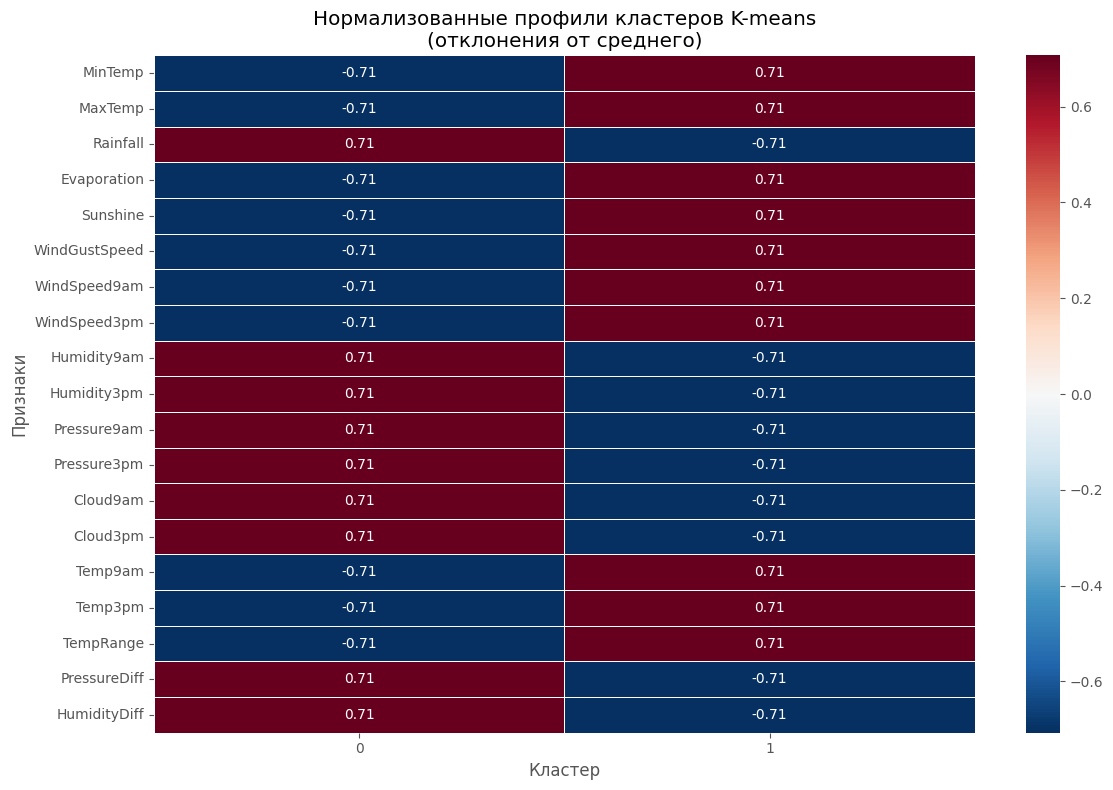

In [87]:
# Heatmap профилей кластеров
print("HEATMAP ПРОФИЛЕЙ КЛАСТЕРОВ:")
print("="*35)

# Нормализованные профили кластеров для heatmap (только числовые столбцы)
numeric_centers = centers_df.drop('Cluster', axis=1)
cluster_profiles_normalized = (numeric_centers - numeric_centers.mean()) / numeric_centers.std()

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles_normalized.T, annot=True, cmap='RdBu_r', center=0,
           fmt='.2f', linewidths=0.5)
plt.title('Нормализованные профили кластеров K-means\n(отклонения от среднего)')
plt.xlabel('Кластер')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ ПО КЛАСТЕРАМ:
Доступные признаки для сравнения: ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am']


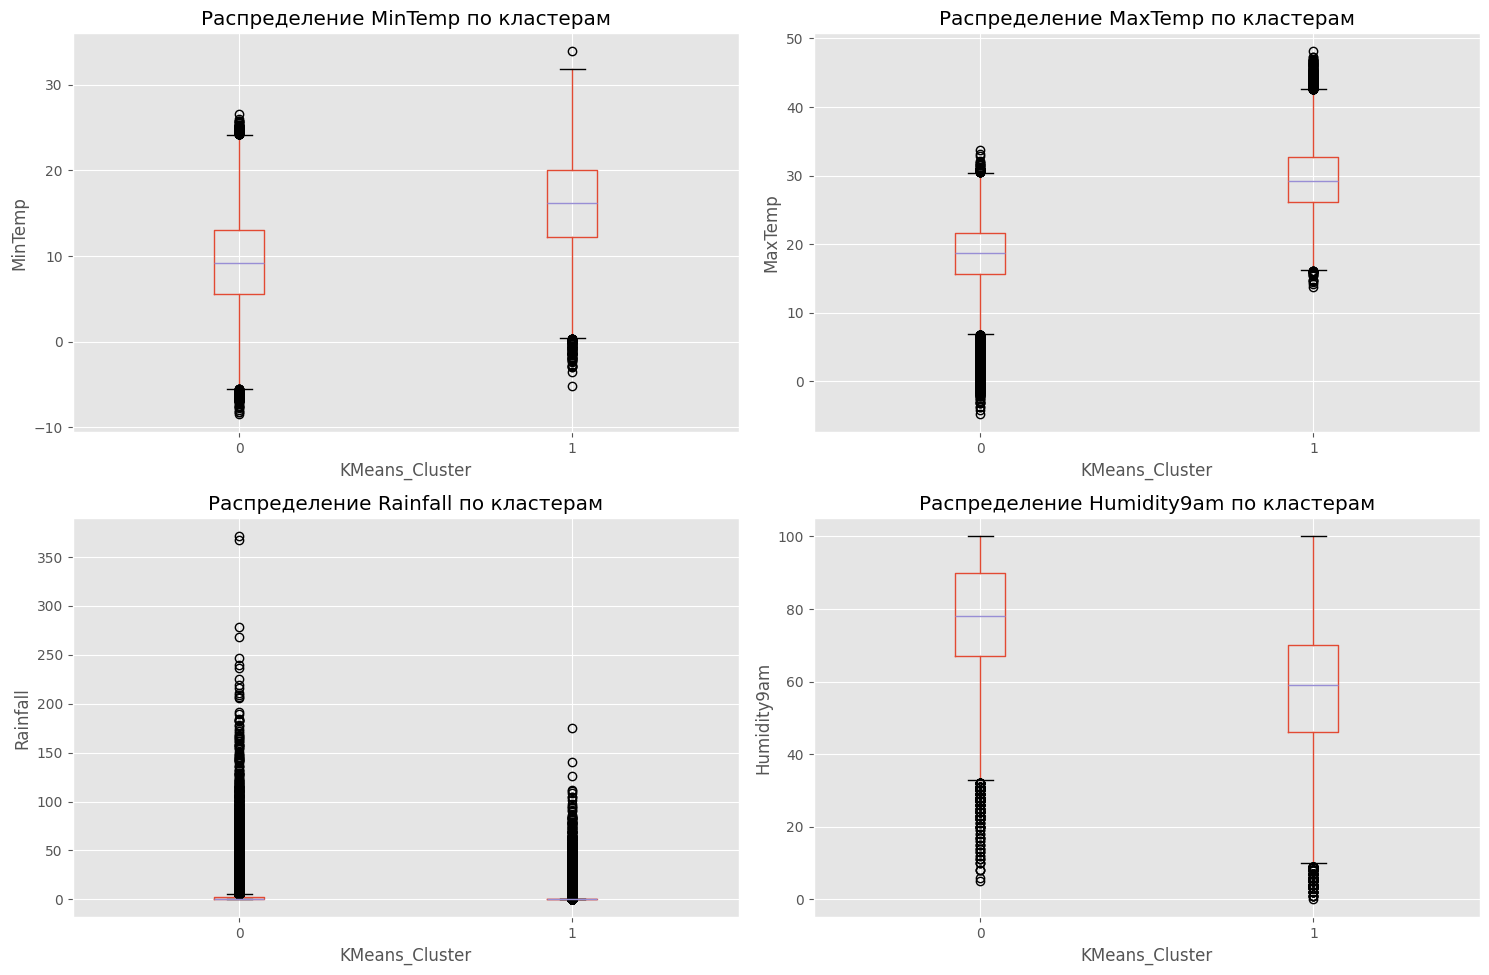

In [93]:
# Сравнение распределений ключевых признаков по кластерам
print("СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ ПО КЛАСТЕРАМ:")
print("="*50)

# Используем признаки, которые точно есть в данных
key_features_comparison = [col for col in ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am'] 
                          if col in df_analysis.columns]

print(f"Доступные признаки для сравнения: {key_features_comparison}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features_comparison):
    if i < len(axes):  # Защита от выхода за границы
        df_analysis.boxplot(column=feature, by='KMeans_Cluster', ax=axes[i])
        axes[i].set_title(f'Распределение {feature} по кластерам')
        axes[i].set_ylabel(feature)
        axes[i].get_figure().suptitle('') 

# Скрываем пустые subplots
for i in range(len(key_features_comparison), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

PARALLEL COORDINATES - МНОГОМЕРНАЯ ВИЗУАЛИЗАЦИЯ:
Признаки для parallel coordinates: ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am']


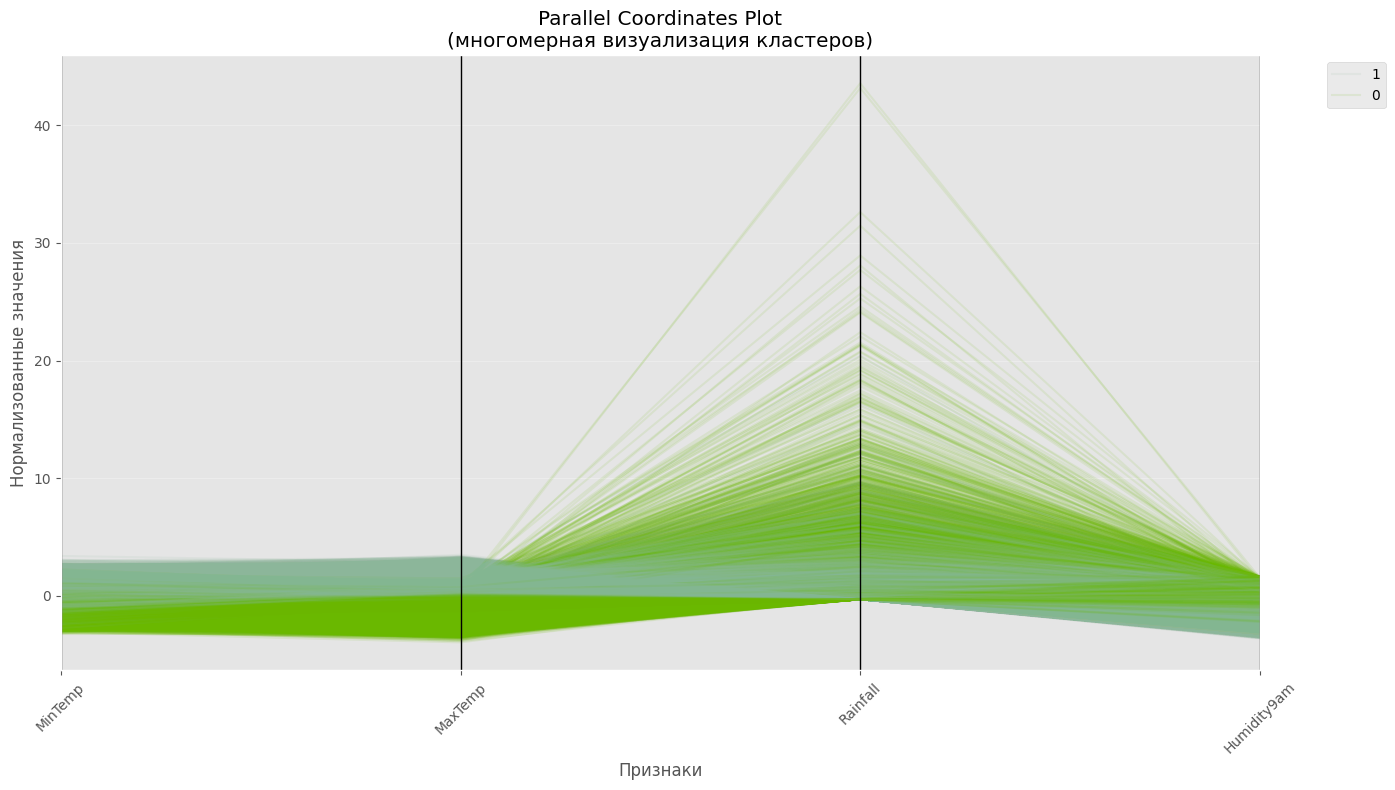

In [90]:
from pandas.plotting import parallel_coordinates

print("PARALLEL COORDINATES - МНОГОМЕРНАЯ ВИЗУАЛИЗАЦИЯ:")
print("="*55)

# Используем только доступные признаки
available_for_parallel = [col for col in key_features_comparison if col in df_analysis.columns]
parallel_data = df_analysis[['KMeans_Cluster'] + available_for_parallel].copy()

print(f"Признаки для parallel coordinates: {available_for_parallel}")

# Нормализуем данные для лучшей визуализации
for feature in available_for_parallel:
    parallel_data[feature] = (parallel_data[feature] - parallel_data[feature].mean()) / parallel_data[feature].std()

plt.figure(figsize=(14, 8))
parallel_coordinates(parallel_data, 'KMeans_Cluster', alpha=0.1)
plt.title('Parallel Coordinates Plot\n(многомерная визуализация кластеров)')
plt.xlabel('Признаки')
plt.ylabel('Нормализованные значения')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ФИНАЛЬНАЯ СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ:
Вычисление t-SNE проекции...


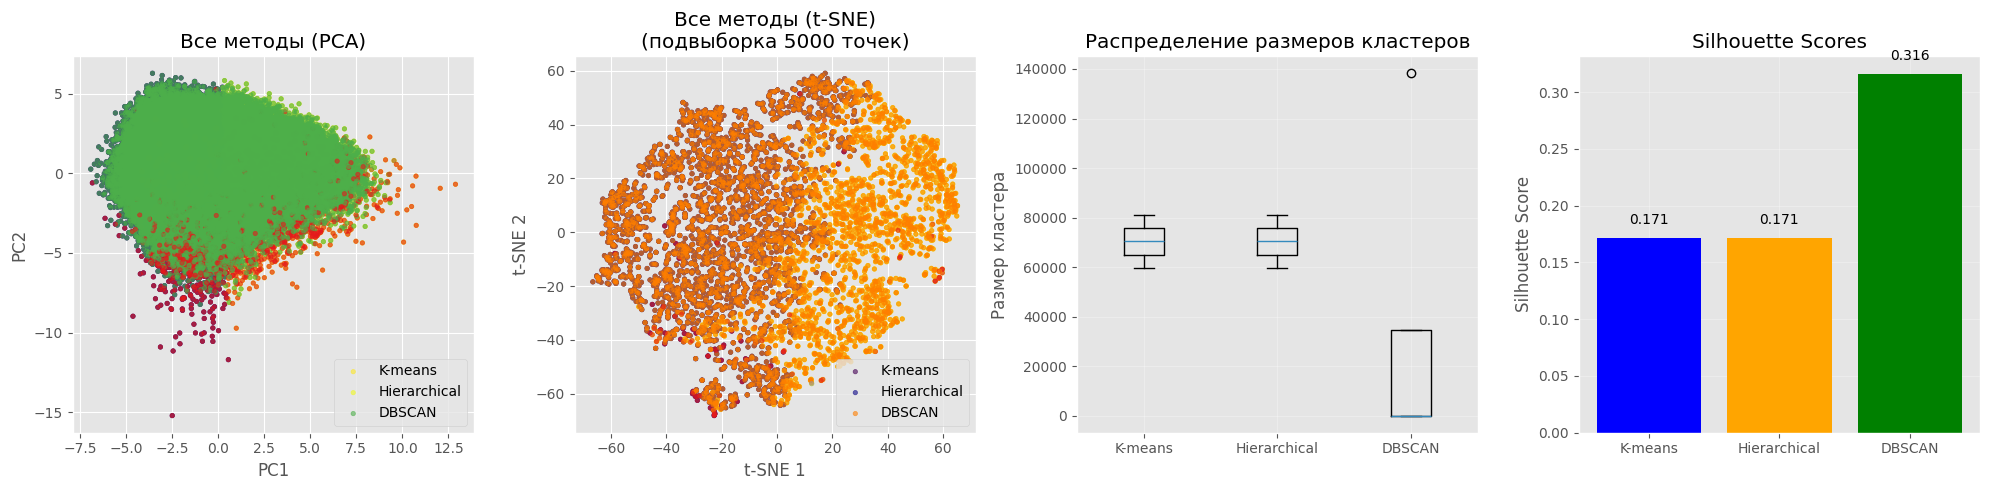

In [92]:
# Финальная сравнительная визуализация всех методов
print("ФИНАЛЬНАЯ СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ:")
print("="*45)

# Создаем subplot с разными проекциями
fig = plt.figure(figsize=(20, 5))

# 1. PCA проекция
ax1 = fig.add_subplot(141)
models_to_plot = []

if 'KMeans_Cluster' in df_analysis.columns:
    models_to_plot.append(('K-means', kmeans_labels, 'viridis'))
if 'Hierarchical_Cluster' in df_analysis.columns:
    models_to_plot.append(('Hierarchical', hierarchical_labels, 'plasma'))
if 'DBSCAN_Cluster' in df_analysis.columns and df_analysis['DBSCAN_Cluster'].nunique() > 1:
    models_to_plot.append(('DBSCAN', dbscan_labels, 'Set1'))

for i, (name, labels, cmap) in enumerate(models_to_plot):
    ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap=cmap, 
               alpha=0.6, s=10, label=name)
ax1.set_title('Все методы (PCA)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()

# 2. t-SNE проекция (альтернатива PCA)
from sklearn.manifold import TSNE

print("Вычисление t-SNE проекции...")
# Используем подвыборку для скорости
sample_size_tsne = min(5000, len(X_scaled))
sample_indices_tsne = np.random.choice(len(X_scaled), sample_size_tsne, replace=False)
X_sample_tsne = X_scaled[sample_indices_tsne]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample_tsne)

ax2 = fig.add_subplot(142)
for i, (name, labels, cmap) in enumerate(models_to_plot):
    sample_labels = labels[sample_indices_tsne]
    ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sample_labels, cmap=cmap, 
               alpha=0.6, s=10, label=name)
ax2.set_title('Все методы (t-SNE)\n(подвыборка 5000 точек)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend()

# 3. Сравнение размеров кластеров
ax3 = fig.add_subplot(143)
cluster_sizes_data = []
model_names = []

for name, labels, _ in models_to_plot:
    sizes = pd.Series(labels).value_counts().sort_index()
    # Для DBSCAN исключаем шум из анализа размеров
    if name == 'DBSCAN' and -1 in sizes.index:
        sizes = sizes.drop(-1)
    if len(sizes) > 0:
        cluster_sizes_data.append(sizes.values)
        model_names.append(name)

if cluster_sizes_data:
    ax3.boxplot(cluster_sizes_data, labels=model_names)
    ax3.set_title('Распределение размеров кластеров')
    ax3.set_ylabel('Размер кластера')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Нет данных\nдля сравнения', 
            ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Распределение размеров кластеров')

# 4. Сравнение silhouette scores
ax4 = fig.add_subplot(144)
silhouette_scores = []

for name, labels, _ in models_to_plot:
    if len(set(labels)) > 1:  # Только если есть хотя бы 2 кластера
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(0)

if silhouette_scores:
    bars = ax4.bar(range(len(models_to_plot)), silhouette_scores, 
                  color=['blue', 'orange', 'green'][:len(models_to_plot)])
    ax4.set_title('Silhouette Scores')
    ax4.set_ylabel('Silhouette Score')
    ax4.set_xticks(range(len(models_to_plot)))
    ax4.set_xticklabels([name for name, _, _ in models_to_plot])
    ax4.grid(True, alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, score in zip(bars, silhouette_scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom')
else:
    ax4.text(0.5, 0.5, 'Нет данных\nдля сравнения', 
            ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Silhouette Scores')

plt.tight_layout()
plt.show()